# Language vs Visual — Is Picture-Naming Neural Activity More Language- or Vision-Like?

This notebook merges the two former `language_vs_visual*` notebooks into a single analysis,
**ordered strongest-evidence-first** for the question: *does ECoG high-gamma activity during
picture naming carry information more like a **language** embedding space or a **visual** one?*

| Order | Section | Evidence | Stream / source |
|---|---|---|---|
| **1** | Direct language-vs-visual decoding contrast | **Strongest** — neural activity decoded into language vs visual embedding *families*, 12 patients, time-resolved, paired LMM | `results/semantic_regression/*picture_naming*cosine*` |
| 2 | Kernel-PLS embedding model comparison | Peak-level cross-check (AA/RB/VB; +FastText/SimCLR, 4 model variants) | `tests/results/model_comparison_*.csv` |
| 3 | DySO — lexical vs visual unique subspaces | Neural-geometry test (which *unique* subspace fits the neural RDM) | `tests/results/lexical_visual_dyso_*` |
| 4 | Cross-task picture↔auditory alignment | Indirect — shared semantic geometry with auditory naming | `tests/results/cross_task_regression/` |
| 5 | Vision layer-depth profiles | Control — do deeper vision layers catch up? *(runs only if `layer_sweep.csv` present)* | `tests/results/layer_sweep.csv` |
| — | Synthesis & conclusion | Weight-of-evidence table | — |

All figures are written to `main/figures/language_vs_visual/` (numbered to match the section order).

> The previous *embedding-space PCA/RSA* section was dropped — it characterised the embedding
> spaces themselves, not the neural signal.


## Setup — imports, paths & config


In [1]:
import sys
import glob
import json
import pathlib
import warnings
warnings.filterwarnings('ignore')
from pathlib import Path

import numpy as np
import pandas as pd
from scipy import stats
import statsmodels.formula.api as smf
from statsmodels.stats.multitest import multipletests

import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.ticker as mticker
import seaborn as sns

# ── Resolve main/ robustly (cwd may be notebooks/ or main/); use ABSOLUTE paths, no chdir ──
_cwd = Path.cwd()
if _cwd.name == 'notebooks':
    MAIN_DIR = _cwd.parent
elif (_cwd / 'notebooks').exists() and (_cwd / 'results').exists():
    MAIN_DIR = _cwd
else:
    MAIN_DIR = Path('..').resolve()
MAIN_DIR = MAIN_DIR.resolve()
if str(MAIN_DIR) not in sys.path:
    sys.path.insert(0, str(MAIN_DIR))

from report.helper.results_loader import load_patient_from_pkl

# ── Result/data directories (renamed to avoid the two notebooks' RESULTS_DIR collision) ──
SEM_RESULTS_DIR   = MAIN_DIR / 'results' / 'semantic_regression'    # notebook-A stream
TESTS_RESULTS_DIR = MAIN_DIR / 'tests' / 'results'                  # notebook-B streams
CROSS_TASK_DIR    = TESTS_RESULTS_DIR / 'cross_task_regression'
# -- Centralized run selection: default to the LATEST cosine run of each task --
def _latest_run(results_dir, pattern):
    folders = sorted(glob.glob(str(results_dir / pattern) + '/'))
    return Path(folders[-1]) if folders else None
PIC_RUN_DIR = _latest_run(SEM_RESULTS_DIR, '*picture_naming*cosine*')
AUD_RUN_DIR = _latest_run(SEM_RESULTS_DIR, '*auditory_naming*cosine*')
print(f'PIC_RUN  : {PIC_RUN_DIR.name if PIC_RUN_DIR else None}')
print(f'AUD_RUN  : {AUD_RUN_DIR.name if AUD_RUN_DIR else None}')
EMB_DIR           = MAIN_DIR / 'embeddings' / 'pictureNaming extended all'

# ── Every figure this notebook makes is written here ──
FIG_DIR = MAIN_DIR / 'figures' / 'language_vs_visual'
FIG_DIR.mkdir(parents=True, exist_ok=True)
SRC_DIR = FIG_DIR / 'source_data'   # source data: arrays/tables directly plotted on the figures
SRC_DIR.mkdir(parents=True, exist_ok=True)

# ── Embedding config — notebook-A semantic-regression stream (12 patients, time-resolved) ──
EMBEDDING_NAMES = ['GloVe', 'Word2Vec', 'ConceptNet', 'DINOv2Small', 'DINOv3', 'MoCo']
SEM_MODELS = {'GloVe', 'Word2Vec', 'ConceptNet'}        # language family
VIS_MODELS = {'DINOv2Small', 'DINOv3', 'MoCo'}          # visual family

BIN_SIZE = 100   # ms per time bin
ALPHA    = 0.001
CACHE_PATH = SRC_DIR / 'cache_null_means_100ep.csv'

_palette = sns.color_palette('tab10', 6)
EMB_COLORS = dict(zip(EMBEDDING_NAMES, _palette))

METRICS = [
    ('r2',        'r2_mean',             'R²',                      'R² (above chance)'),
    ('word',      'word_balanced_acc',   'Word Balanced Acc',       'Word Acc − Chance'),
    ('category',  'category_balanced_acc','Category Balanced Acc',  'Cat Acc − Chance'),
]

# language × visual pairs for the pairwise test (Section 1b)
COMPARE_PAIRS = [
    ('GloVe',    'DINOv2Small'), ('GloVe',    'DINOv3'), ('GloVe',    'MoCo'),
    ('Word2Vec', 'DINOv2Small'), ('Word2Vec', 'DINOv3'), ('Word2Vec', 'MoCo'),
]

# ── Embedding config — notebook-B streams (model comparison / layer sweep; different result files) ──
LANG_COLOR = {'GloVe': '#1565C0', 'FastText': '#0288D1',
              'Word2Vec': '#00838F', 'ConceptNet': '#2E7D32'}     # language → blue family
VIS_COLOR  = {'DINOv2': '#E65100', 'SimCLR': '#AD1457'}           # vision → warm family
EMBED_COLOR = {**LANG_COLOR, **VIS_COLOR}

plt.rcParams.update({'figure.dpi': 110,
                     'axes.spines.top': False, 'axes.spines.right': False})

print(f"MAIN_DIR : {MAIN_DIR}")
print(f"FIG_DIR  : {FIG_DIR}")
print(f"Embeddings (A stream): {EMBEDDING_NAMES}")
print(f"Semantic: {SEM_MODELS}  |  Visual: {VIS_MODELS}")


PIC_RUN  : 2026-06-02_17-25-11_picture_naming_kernel_pls_cosine_100ep
AUD_RUN  : 2026-05-07_22-26-06_auditory_naming_warp-linear_align-aud_stim_onset_kernel_pls_cosine_50ep
MAIN_DIR : D:\OneDrive - Northwestern University\PycharmProjects\Speech\main
FIG_DIR  : D:\OneDrive - Northwestern University\PycharmProjects\Speech\main\figures\language_vs_visual
Embeddings (A stream): ['GloVe', 'Word2Vec', 'ConceptNet', 'DINOv2Small', 'DINOv3', 'MoCo']
Semantic: {'ConceptNet', 'Word2Vec', 'GloVe'}  |  Visual: {'MoCo', 'DINOv3', 'DINOv2Small'}


## Data foundation — per-time scores, PKL nulls & group significance

Loads `per_time_scores.csv` and the per-patient PKLs (cached), then fits a per-bin linear
mixed-effects model (random intercept per patient, one-sided > 0, FDR across bins) to get
`sig_df`. This machinery feeds **Section 1** (the family contrast *and* its granular backbone).


In [2]:
SEM_RESULTS_DIR = MAIN_DIR / 'results' / 'semantic_regression'
run_folders = [PIC_RUN_DIR]   # latest picture-naming run (centralized in config cell)
print(f"Found {len(run_folders)} picture-naming cosine run folder(s):")
for r in run_folders:
    print(f"  {pathlib.Path(r).name}")

pts_frames = []
for run_path in run_folders:
    run_id = pathlib.Path(run_path).name
    csv_files = glob.glob(str(pathlib.Path(run_path) / '*' / 'per_time_scores.csv'))
    for csv_path in sorted(csv_files):
        df_tmp = pd.read_csv(csv_path)
        df_tmp['run_id'] = run_id
        pts_frames.append(df_tmp)

df_pts = pd.concat(pts_frames, ignore_index=True)
df_pts['time_ms'] = df_pts['bin_index'] * BIN_SIZE

# ── Report ──────────────────────────────────────────────────────────────────
patients   = sorted(df_pts['patient'].unique())
embeddings = [e for e in EMBEDDING_NAMES if e in df_pts['embedding'].unique()]
time_bins  = sorted(df_pts['bin_index'].unique())
print(f"\nLoaded: {len(patients)} patients × {len(embeddings)} embeddings × {len(time_bins)} bins")
print(f"Patients : {patients}")
print(f"Time range: {min(time_bins)*BIN_SIZE}–{max(time_bins)*BIN_SIZE} ms")
print(f"\nColumns: {list(df_pts.columns)}")
df_pts.head(3)


Found 1 picture-naming cosine run folder(s):
  2026-06-02_17-25-11_picture_naming_kernel_pls_cosine_100ep

Loaded: 12 patients × 6 embeddings × 80 bins
Patients : ['AA', 'AP', 'AZ', 'CP', 'DR', 'EH', 'EM', 'LH', 'MM', 'RB', 'VB', 'WBH']
Time range: 0–7900 ms

Columns: ['patient', 'embedding', 'bin_index', 'r2_mean', 'r2_std', 'cosine_mean', 'cosine_std', 'chance_mean', 'word_balanced_acc', 'category_balanced_acc', 'category_balanced_acc_indep', 'word_f1', 'category_f1', 'word_top3_acc', 'word_top5_acc', 'word_loose_acc', 'category_loose_acc', 'run_id', 'time_ms']


,patient,embedding,bin_index,r2_mean,r2_std,cosine_mean,cosine_std,chance_mean,word_balanced_acc,category_balanced_acc,category_balanced_acc_indep,word_f1,category_f1,word_top3_acc,word_top5_acc,word_loose_acc,category_loose_acc,run_id,time_ms
0,AA,GloVe,0,-0.102633,0.018697,0.008240,0.016476,-0.077094,0.019959,0.171340,0.182983,0.010168,0.160520,0.059510,0.091275,0.023137,0.211275,2026-06-02_17-25-11_picture_naming_kernel_pls_...,0
1,AA,GloVe,1,-0.097078,0.016633,0.011729,0.017367,-0.078873,0.018345,0.169581,0.178258,0.009440,0.154599,0.061078,0.095588,0.022451,0.214020,2026-06-02_17-25-11_picture_naming_kernel_pls_...,100
2,AA,GloVe,2,-0.097307,0.016522,0.003097,0.016475,-0.071657,0.015600,0.157826,0.166802,0.008580,0.143561,0.057941,0.090490,0.017843,0.202451,2026-06-02_17-25-11_picture_naming_kernel_pls_...,200


In [3]:
def load_and_extract_pkl_data(run_folders, patients, embeddings):
    """Load PKLs and return df_null with per-patient per-bin means."""
    null_records = []

    for run_path in run_folders:
        run_id = pathlib.Path(run_path).name
        for patient in patients:
            pkl_path = pathlib.Path(run_path) / patient / 'semantic_regression_results.pkl'
            if not pkl_path.exists():
                print(f"  [skip] {patient}: no PKL found")
                continue

            print(f"  Loading {patient}...", end=' ', flush=True)
            pkl_data = load_patient_from_pkl(str(pkl_path))
            if pkl_data is None:
                print("SKIPPED (too large or error)")
                continue
            print(f"OK ({len(pkl_data)} embeddings)")

            for emb in embeddings:
                if emb not in pkl_data:
                    continue
                d = pkl_data[emb]
                cat_obs  = np.array(d['cat_obs'])   # (n_epochs, n_bins)
                cat_null = np.array(d['cat_null'])
                word_obs  = np.array(d['word_obs'])
                word_null = np.array(d['word_null'])
                n_bins = cat_obs.shape[1]

                for b in range(n_bins):
                    # Per-patient means across epochs
                    null_records.append({
                        'run_id':        run_id,
                        'patient':       patient,
                        'embedding':     emb,
                        'bin_index':     b,
                        'time_ms':       b * BIN_SIZE,
                        'cat_obs_mean':  float(cat_obs[:, b].mean()),
                        'cat_null_mean': float(cat_null[:, b].mean()),
                        'word_obs_mean': float(word_obs[:, b].mean()),
                        'word_null_mean':float(word_null[:, b].mean()),
                    })

    return pd.DataFrame(null_records)


# ── Load  ──────────────────────────────────────────────────────

print("Loading PKL files (this may take 10–20 s)...")
df_null = load_and_extract_pkl_data(run_folders, patients, embeddings)
df_null.to_csv(CACHE_PATH, index=False)
print(f"\nSaved cache to {CACHE_PATH}")

print(f"\ndf_null shape: {df_null.shape}")

# ── Trim to shortest patient (consistent time axis) ───────────────────────────
_max_bin_pts  = df_pts.groupby('patient')['bin_index'].max().min()
_max_bin_null = df_null.groupby('patient')['bin_index'].max().min()
MAX_BIN_INDEX = int(min(_max_bin_pts, _max_bin_null))

df_pts  = df_pts[df_pts['bin_index']  <= MAX_BIN_INDEX].copy()
df_null = df_null[df_null['bin_index'] <= MAX_BIN_INDEX].copy()

# Refresh time_bins so downstream cells see the trimmed range
time_bins = sorted(df_pts['bin_index'].unique())
print(f"Trimmed to {MAX_BIN_INDEX + 1} bins (0–{MAX_BIN_INDEX * BIN_SIZE} ms) — shortest-patient constraint")
print(f"df_pts rows: {len(df_pts)},  df_null rows: {len(df_null)}")
df_null.head(3)


Loading PKL files (this may take 10–20 s)...
  Loading AA... OK (6 embeddings)
  Loading AP... OK (6 embeddings)
  Loading AZ... OK (6 embeddings)
  Loading CP... OK (6 embeddings)
  Loading DR... OK (6 embeddings)
  Loading EH... OK (6 embeddings)
  Loading EM... OK (6 embeddings)
  Loading LH... OK (6 embeddings)
  Loading MM... OK (6 embeddings)
  Loading RB... OK (6 embeddings)
  Loading VB... OK (6 embeddings)
  Loading WBH... OK (6 embeddings)

Saved cache to D:\OneDrive - Northwestern University\PycharmProjects\Speech\main\figures\language_vs_visual\source_data\cache_null_means_100ep.csv

df_null shape: (3942, 9)
Trimmed to 50 bins (0–4900 ms) — shortest-patient constraint
df_pts rows: 3600,  df_null rows: 3600


,run_id,patient,embedding,bin_index,time_ms,cat_obs_mean,cat_null_mean,word_obs_mean,word_null_mean
0,2026-06-02_17-25-11_picture_naming_kernel_pls_...,AA,GloVe,0,0,0.171340,0.169679,0.019959,0.016167
1,2026-06-02_17-25-11_picture_naming_kernel_pls_...,AA,GloVe,1,100,0.169581,0.167769,0.018345,0.016374
2,2026-06-02_17-25-11_picture_naming_kernel_pls_...,AA,GloVe,2,200,0.157826,0.173233,0.015600,0.015424


In [4]:
def compute_group_significance(df_null, df_pts, embeddings):
    """
    Compute group-level significance using a linear mixed-effects model.

    For each (embedding, metric), fits:
        effect ~ 0 + C(bin_index), groups=patient
    with a random intercept. One-sided test of estimated mean > 0 per bin.
    FDR correction across bins per (embedding, metric).

    Returns
    -------
    sig_df : pd.DataFrame
        One row per (embedding, bin_index, metric) with columns:
        effect, se, ci_lower, ci_upper, mean_obs, mean_null, sem_obs,
        n_patients, p_raw, p_fdr, significant, tau2, method
    """
    # ── Build long-form effect table ────────────────────────────────────────
    effect_rows = []

    for emb in embeddings:
        emb_null = df_null[df_null['embedding'] == emb]
        emb_pts  = df_pts[df_pts['embedding'] == emb]

        # Category & Word from PKL null
        for metric_key, obs_col, null_col in [
            ('category', 'cat_obs_mean',  'cat_null_mean'),
            ('word',     'word_obs_mean', 'word_null_mean'),
        ]:
            for _, row in emb_null.iterrows():
                effect_rows.append({
                    'patient':   row['patient'],
                    'embedding': emb,
                    'bin_index': int(row['bin_index']),
                    'time_ms':   int(row['bin_index']) * BIN_SIZE,
                    'metric':    metric_key,
                    'obs':       float(row[obs_col]),
                    'null':      float(row[null_col]),
                    'effect':    float(row[obs_col] - row[null_col]),
                })

        # R² from per_time_scores.csv
        for _, row in emb_pts.iterrows():
            effect_rows.append({
                'patient':   row['patient'],
                'embedding': emb,
                'bin_index': int(row['bin_index']),
                'time_ms':   int(row['bin_index']) * BIN_SIZE,
                'metric':    'r2',
                'obs':       float(row['r2_mean']),
                'null':      float(row['chance_mean']),
                'effect':    float(row['r2_mean'] - row['chance_mean']),
            })

    long_df = pd.DataFrame(effect_rows)

    # ── Fit LMM per (embedding, metric) ─────────────────────────────────────
    records = []

    for (emb, metric), subset in long_df.groupby(['embedding', 'metric']):
        subset = subset.sort_values(['patient', 'bin_index']).copy()

        try:
            model = smf.mixedlm(
                "effect ~ 0 + C(bin_index)",
                data=subset,
                groups=subset["patient"],
            )
            result = model.fit(reml=True)
            tau2 = float(result.cov_re.iloc[0, 0])
            ci_df = result.conf_int()
        except Exception as e:
            raise RuntimeError(f"LMM failed for {emb}/{metric}: {e}")

        for param_name in result.fe_params.index:
            # Parse bin index: 'C(bin_index)[0]' or 'C(bin_index)[T.0]'
            b_str = param_name.rsplit('[', 1)[1].rstrip(']')
            if b_str.startswith('T.'):
                b_str = b_str[2:]
            b = int(float(b_str))

            estimate = float(result.fe_params[param_name])
            se = float(result.bse[param_name])
            p_two = float(result.pvalues[param_name])
            # One-sided: H1: effect > 0
            p_one = p_two / 2 if estimate > 0 else 1.0 - p_two / 2
            ci_lo = float(ci_df.loc[param_name].iloc[0])
            ci_hi = float(ci_df.loc[param_name].iloc[1])

            bin_data = subset[subset['bin_index'] == b]
            records.append({
                'embedding':  emb,
                'bin_index':  b,
                'time_ms':    b * BIN_SIZE,
                'metric':     metric,
                'effect':     estimate,
                'se':         se,
                'ci_lower':   ci_lo,
                'ci_upper':   ci_hi,
                'mean_obs':   float(bin_data['obs'].mean()),
                'mean_null':  float(bin_data['null'].mean()),
                'sem_obs':    float(bin_data['obs'].std(ddof=1) / np.sqrt(len(bin_data))),
                'n_patients': len(bin_data),
                'p_raw':      p_one,
                'tau2':       tau2,
                'method':     'lmm',
            })

    df = pd.DataFrame(records)

    # FDR correction across bins per (embedding, metric)
    fdr_corrected = []
    for (emb, metric), grp in df.groupby(['embedding', 'metric']):
        p_vals = grp['p_raw'].values
        if len(p_vals) < 2:
            fdr = p_vals.copy()
        else:
            _, fdr, _, _ = multipletests(p_vals, alpha=ALPHA, method='fdr_bh')
        grp = grp.copy()
        grp['p_fdr'] = fdr
        fdr_corrected.append(grp)

    df = pd.concat(fdr_corrected, ignore_index=True)
    df['significant'] = df['p_fdr'] < ALPHA
    return df.sort_values(['embedding', 'metric', 'bin_index']).reset_index(drop=True)


sig_df = compute_group_significance(df_null, df_pts, embeddings)
print(f"sig_df shape: {sig_df.shape}")
n_sig = sig_df['significant'].sum()
print(f"Significant (p_fdr < {ALPHA}): {n_sig}/{len(sig_df)} cells")
methods = sig_df['method'].value_counts()
print(f"Methods used: {methods.to_dict()}")
print(f"Mean τ² (patient variance): {sig_df['tau2'].mean():.6f}")
sig_df.groupby(['metric', 'embedding'])['significant'].sum().unstack('embedding')


sig_df shape: (900, 17)
Significant (p_fdr < 0.001): 265/900 cells
Methods used: {'lmm': 900}
Mean τ² (patient variance): 0.000281


embedding,ConceptNet,DINOv2Small,DINOv3,GloVe,MoCo,Word2Vec
metric,,,,,,
category,21,19,21,20,21,20
r2,7,0,0,10,0,10
word,22,18,19,19,19,19


In [5]:
def _get_per_patient_effect(df_pts, df_null, embeddings, metric_key):
    """
    Return dict[emb] -> dict[patient] -> array(n_bins) of (obs - null).
    For R²: uses df_pts; for word/category: uses df_null.
    """
    result = {emb: {} for emb in embeddings}

    if metric_key == 'r2':
        for emb in embeddings:
            sub = df_pts[df_pts['embedding'] == emb].sort_values(['patient', 'bin_index'])
            for pat, g in sub.groupby('patient'):
                g = g.sort_values('bin_index')
                result[emb][pat] = (g['r2_mean'].values - g['chance_mean'].values)
    else:
        obs_col  = 'cat_obs_mean'  if metric_key == 'category' else 'word_obs_mean'
        null_col = 'cat_null_mean' if metric_key == 'category' else 'word_null_mean'
        for emb in embeddings:
            sub = df_null[df_null['embedding'] == emb].sort_values(['patient', 'bin_index'])
            for pat, g in sub.groupby('patient'):
                g = g.sort_values('bin_index')
                result[emb][pat] = (g[obs_col].values - g[null_col].values)
    return result


---
## Section 1 — Direct language-vs-visual decoding contrast  **(STRONGEST)**

### 1a · Family contrast — what is the neural activity *more similar to*?

The three figures below collapse the six embeddings into two **families** — language
(GloVe, Word2Vec, ConceptNet) and visual (DINOv2Small, DINOv3, MoCo) — and ask which
the ECoG high-gamma activity resembles more. Higher above-chance decoding accuracy into a
family = the neural activity carries more information structured like that family, i.e. is
*more similar* to it. Per request, the measurement is **Word Acc & Category Acc** only (R² omitted).

- **Fig 7 — Family time course.** Language-family mean vs visual-family mean (each patient's
  within-family average) across time, plus the paired Language−Visual difference tested per
  bin with an LMM (two-sided, FDR q<0.05). Significant bins are shaded by the winning family.
- **Fig 8 — Per-patient preference.** Each patient's mean post-stimulus effect, language (x)
  vs visual (y); points below the diagonal are language-preferring. Wilcoxon signed-rank
  across patients tests whether the lean is consistent.
- **Fig 9 — Temporal dominance.** Fraction of patients with Language > Visual at each bin
  (dots = binomial p<0.05 vs 0.5) — exposes any early-visual → late-language crossover.

> Uses the data foundation above (`df_pts`, `df_null`, `embeddings`, `_get_per_patient_effect`).

Language family: ['GloVe', 'Word2Vec', 'ConceptNet']
Visual family  : ['DINOv2Small', 'DINOv3', 'MoCo']


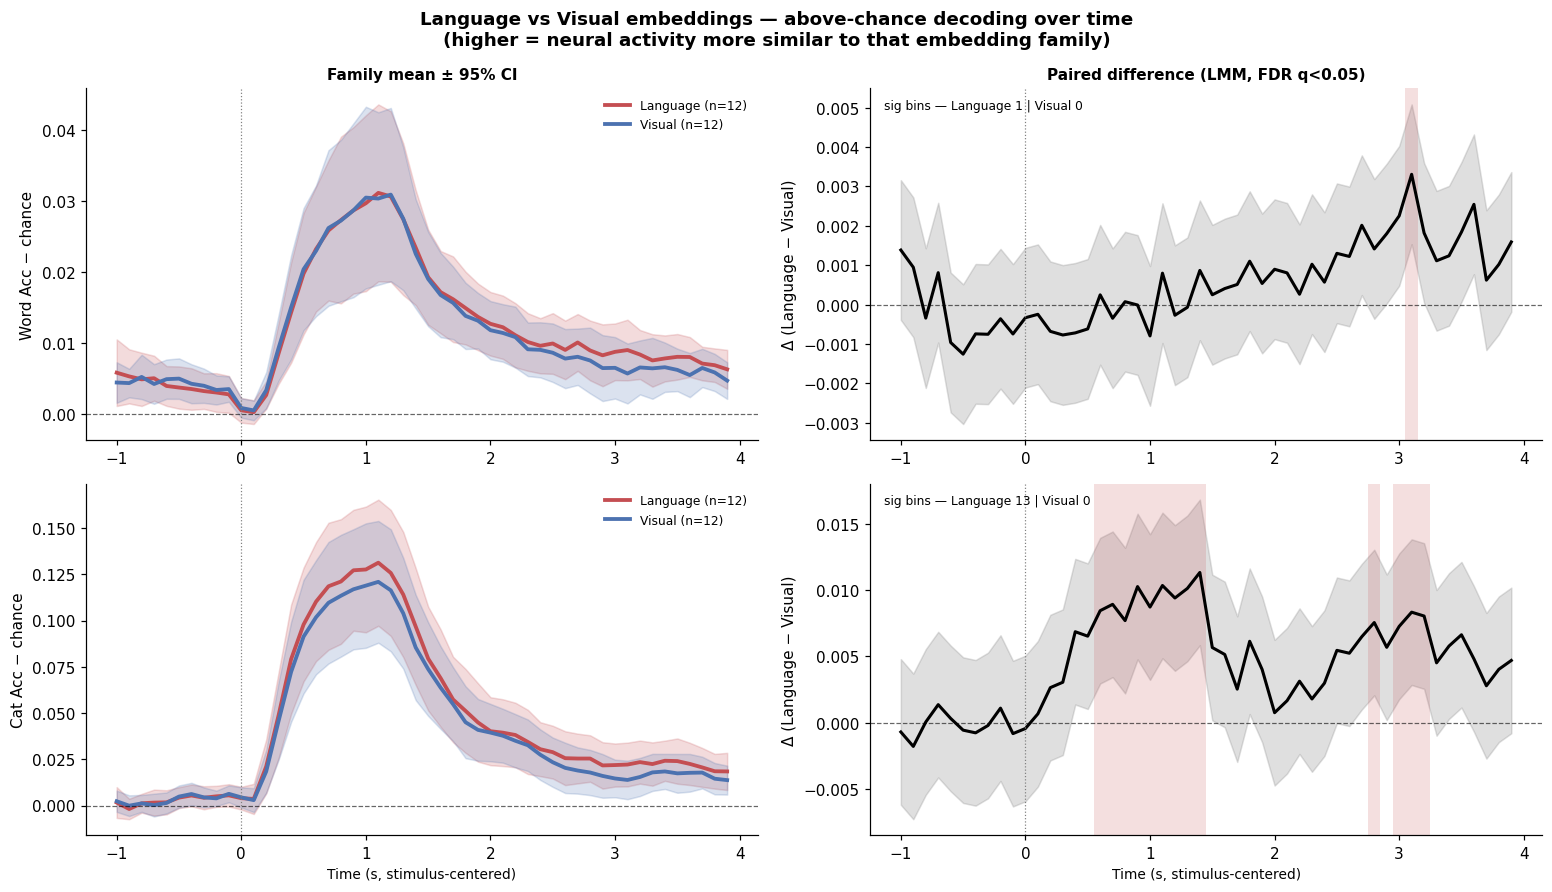

Saved: 01_family_contrast_timeseries.png


In [6]:
# ════════════════════════════════════════════════════════════════════════════
# Language vs Visual family contrast — Word Acc & Cat Acc (above chance)
# ════════════════════════════════════════════════════════════════════════════
from scipy.stats import wilcoxon
try:
    from scipy.stats import binomtest
    def _binom_p(k, n): return binomtest(k, n, 0.5).pvalue
except ImportError:                       # older scipy
    from scipy.stats import binom_test as _bt
    def _binom_p(k, n): return _bt(k, n, 0.5)

PRE_STIM_MS = 1000
MS_PER_SEC  = 1000.0
half_bin_s  = (BIN_SIZE / 2) / MS_PER_SEC

LANG_EMBS = [e for e in EMBEDDING_NAMES if e in SEM_MODELS and e in embeddings]
VIS_EMBS  = [e for e in EMBEDDING_NAMES if e in VIS_MODELS and e in embeddings]
LANG_COLOR, VIS_COLOR = '#c44e52', '#4c72b0'      # warm = language, cool = visual
METRIC_DISPLAY = [('word', 'Word Acc'), ('category', 'Cat Acc')]

n_bins    = MAX_BIN_INDEX + 1
time_s    = (np.arange(n_bins) * BIN_SIZE - PRE_STIM_MS) / MS_PER_SEC
post_bins = np.where(time_s >= 0)[0]              # stimulus onset and after

print(f"Language family: {LANG_EMBS}")
print(f"Visual family  : {VIS_EMBS}")


def _family_effects(family_embs, metric_key):
    """dict[patient] -> array(n_bins): mean above-chance effect across the family."""
    per_emb = _get_per_patient_effect(df_pts, df_null, family_embs, metric_key)
    pat_arrays = {}
    for emb in family_embs:
        for pat, arr in per_emb.get(emb, {}).items():
            pat_arrays.setdefault(pat, []).append(np.asarray(arr, float)[:n_bins])
    return {pat: np.vstack(a).mean(axis=0) for pat, a in pat_arrays.items()}


fam_eff = {
    metric: {'language': _family_effects(LANG_EMBS, metric),
             'visual':   _family_effects(VIS_EMBS,  metric)}
    for metric, _ in METRIC_DISPLAY
}


def _diff_lmm(lang_eff, vis_eff):
    """Per-bin paired (language - visual) LMM; two-sided p, FDR across bins."""
    pats = sorted(set(lang_eff) & set(vis_eff))
    rows = [{'patient': pat, 'bin_index': b, 'diff': float(lang_eff[pat][b] - vis_eff[pat][b])}
            for pat in pats for b in range(n_bins)]
    res = smf.mixedlm("diff ~ 0 + C(bin_index)", data=pd.DataFrame(rows),
                      groups=pd.DataFrame(rows)['patient']).fit(reml=True)
    ci = res.conf_int()
    recs = []
    for pn in res.fe_params.index:
        bs = pn.rsplit('[', 1)[1].rstrip(']'); bs = bs[2:] if bs.startswith('T.') else bs
        b = int(float(bs))
        recs.append({'bin_index': b, 'diff': float(res.fe_params[pn]),
                     'ci_lower': float(ci.loc[pn].iloc[0]), 'ci_upper': float(ci.loc[pn].iloc[1]),
                     'p_raw': float(res.pvalues[pn])})        # two-sided
    d = pd.DataFrame(recs).sort_values('bin_index').reset_index(drop=True)
    _, d['p_fdr'], _, _ = multipletests(d['p_raw'].values, alpha=0.05, method='fdr_bh')
    d['significant'] = d['p_fdr'] < 0.05
    return d, pats


# ── Fig 7: family mean curves + paired difference ────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 8), constrained_layout=True)
fig.suptitle('Language vs Visual embeddings — above-chance decoding over time\n'
             '(higher = neural activity more similar to that embedding family)',
             fontsize=12, fontweight='bold')

for row, (metric, label) in enumerate(METRIC_DISPLAY):
    lang, vis = fam_eff[metric]['language'], fam_eff[metric]['visual']

    # left: family mean ± 95% CI
    axc = axes[row, 0]
    for eff, c, name in [(lang, LANG_COLOR, 'Language'), (vis, VIS_COLOR, 'Visual')]:
        pats = sorted(eff)
        M = np.vstack([eff[p] for p in pats])
        mean = M.mean(0); sem = M.std(0, ddof=1) / np.sqrt(M.shape[0])
        axc.plot(time_s, mean, color=c, lw=2.5, label=f'{name} (n={len(pats)})')
        axc.fill_between(time_s, mean - 1.96 * sem, mean + 1.96 * sem, color=c, alpha=0.20)
    axc.axhline(0, color='k', lw=0.8, ls='--', alpha=0.6)
    axc.axvline(0, color='grey', lw=0.8, ls=':')
    axc.set_ylabel(f'{label} − chance', fontsize=10)
    if row == 0: axc.set_title('Family mean ± 95% CI', fontsize=10, fontweight='bold')
    if row == 1: axc.set_xlabel('Time (s, stimulus-centered)', fontsize=9)
    axc.legend(fontsize=8, frameon=False)
    axc.spines['top'].set_visible(False); axc.spines['right'].set_visible(False)

    # right: paired difference with significance
    d, _ = _diff_lmm(lang, vis)
    axd = axes[row, 1]
    axd.plot(time_s, d['diff'].values, color='black', lw=2)
    axd.fill_between(time_s, d['ci_lower'].values, d['ci_upper'].values, color='grey', alpha=0.25)
    axd.axhline(0, color='k', lw=0.8, ls='--', alpha=0.6)
    axd.axvline(0, color='grey', lw=0.8, ls=':')
    for _, r in d[d['significant']].iterrows():
        ts = time_s[int(r['bin_index'])]
        axd.axvspan(ts - half_bin_s, ts + half_bin_s,
                    color=LANG_COLOR if r['diff'] > 0 else VIS_COLOR, alpha=0.18, lw=0)
    n_lang = int(((d['diff'] > 0) & d['significant']).sum())
    n_vis  = int(((d['diff'] < 0) & d['significant']).sum())
    axd.set_ylabel('Δ (Language − Visual)', fontsize=10)
    if row == 0: axd.set_title('Paired difference (LMM, FDR q<0.05)', fontsize=10, fontweight='bold')
    if row == 1: axd.set_xlabel('Time (s, stimulus-centered)', fontsize=9)
    axd.text(0.02, 0.97, f'sig bins — Language {n_lang} | Visual {n_vis}',
             transform=axd.transAxes, va='top', fontsize=8)
    axd.spines['top'].set_visible(False); axd.spines['right'].set_visible(False)

plt.savefig(FIG_DIR / '01_family_contrast_timeseries.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: 01_family_contrast_timeseries.png')




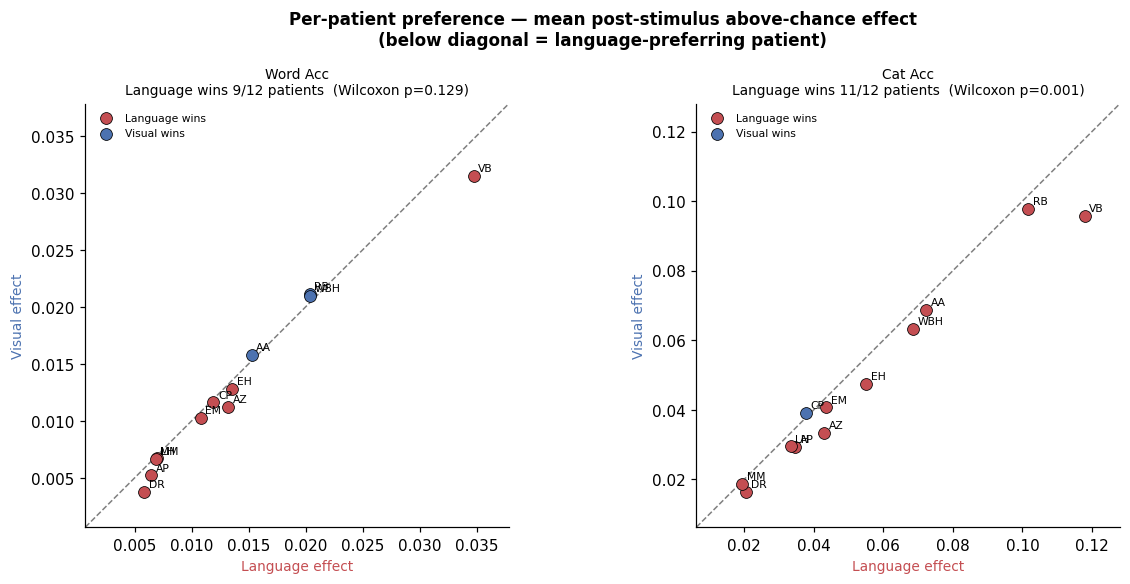

Saved: 02_family_per_patient_preference.png


In [7]:
# ── Fig 8: per-patient paired preference (post-stimulus mean) ────────────────
fig, axes = plt.subplots(1, 2, figsize=(11, 5.2), constrained_layout=True)
fig.suptitle('Per-patient preference — mean post-stimulus above-chance effect\n'
             '(below diagonal = language-preferring patient)', fontsize=11, fontweight='bold')

summary_lines = []
for ax, (metric, label) in zip(axes, METRIC_DISPLAY):
    lang, vis = fam_eff[metric]['language'], fam_eff[metric]['visual']
    pats = sorted(set(lang) & set(vis))
    lx = np.array([lang[p][post_bins].mean() for p in pats])
    vy = np.array([vis[p][post_bins].mean()  for p in pats])
    win_lang = lx > vy

    ax.scatter(lx[win_lang],  vy[win_lang],  color=LANG_COLOR, s=60, zorder=3,
               edgecolor='k', lw=0.5, label='Language wins')
    ax.scatter(lx[~win_lang], vy[~win_lang], color=VIS_COLOR,  s=60, zorder=3,
               edgecolor='k', lw=0.5, label='Visual wins')
    for p, xx, yy in zip(pats, lx, vy):
        ax.annotate(p, (xx, yy), fontsize=7, xytext=(3, 3), textcoords='offset points')

    lo, hi = min(lx.min(), vy.min()), max(lx.max(), vy.max())
    pad = (hi - lo) * 0.10 or 0.001
    ax.plot([lo - pad, hi + pad], [lo - pad, hi + pad], ls='--', color='grey', lw=1)
    ax.set_xlim(lo - pad, hi + pad); ax.set_ylim(lo - pad, hi + pad); ax.set_aspect('equal')

    try:
        _, w_p = wilcoxon(lx, vy)
    except ValueError:
        w_p = np.nan
    n_lw = int(win_lang.sum())
    ax.set_title(f'{label}\nLanguage wins {n_lw}/{len(pats)} patients  (Wilcoxon p={w_p:.3f})', fontsize=9)
    ax.set_xlabel('Language effect', fontsize=9, color=LANG_COLOR)
    ax.set_ylabel('Visual effect',   fontsize=9, color=VIS_COLOR)
    ax.legend(fontsize=7, frameon=False, loc='upper left')
    ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
    summary_lines.append(f'{label:9s}: language mean={lx.mean():.4f}  visual mean={vy.mean():.4f}  '
                         f'language wins {n_lw}/{len(pats)}  Wilcoxon p={w_p:.3f}')

plt.savefig(FIG_DIR / '02_family_per_patient_preference.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: 02_family_per_patient_preference.png')




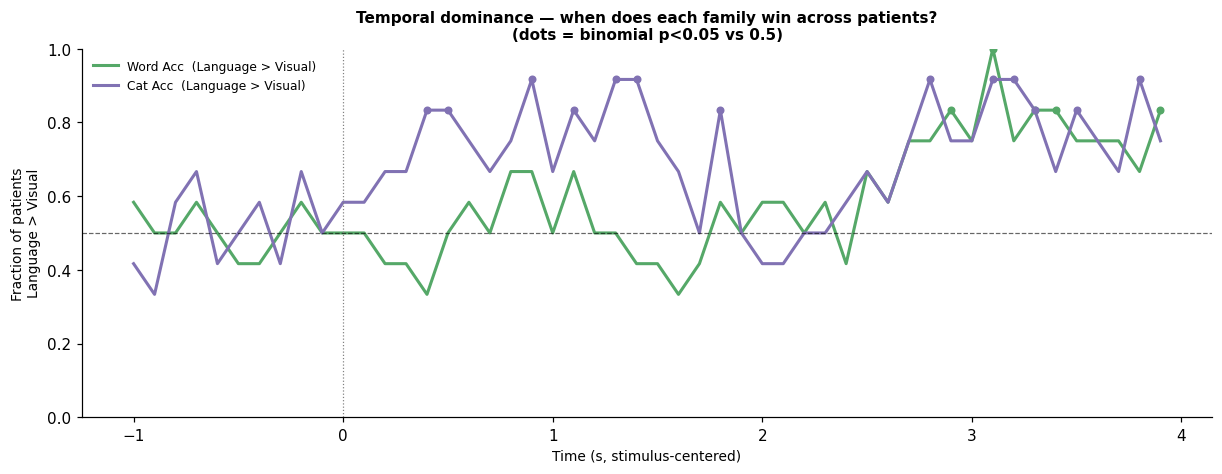

Saved: 03_family_temporal_dominance.png

── Summary: what is neural activity more similar to? (post-stimulus mean) ──
  Word Acc : language mean=0.0138  visual mean=0.0131  language wins 9/12  Wilcoxon p=0.129
  Cat Acc  : language mean=0.0539  visual mean=0.0483  language wins 11/12  Wilcoxon p=0.001


In [8]:
# ── Fig 9: temporal dominance (fraction of patients language > visual) ───────
fig, ax = plt.subplots(figsize=(11, 4.2), constrained_layout=True)
for metric, label, color in [('word', 'Word Acc', '#55a868'), ('category', 'Cat Acc', '#8172b3')]:
    lang, vis = fam_eff[metric]['language'], fam_eff[metric]['visual']
    pats = sorted(set(lang) & set(vis)); npat = len(pats)
    counts = np.array([sum(lang[p][b] > vis[p][b] for p in pats) for b in range(n_bins)])
    frac = counts / npat
    ax.plot(time_s, frac, lw=2, color=color, label=f'{label}  (Language > Visual)')
    sig = np.array([_binom_p(int(counts[b]), npat) < 0.05 for b in range(n_bins)])
    ax.scatter(time_s[sig], frac[sig], color=color, s=18, zorder=5)

ax.axhline(0.5, color='k', lw=0.8, ls='--', alpha=0.6)
ax.axvline(0, color='grey', lw=0.8, ls=':')
ax.set_ylim(0, 1)
ax.set_ylabel('Fraction of patients\nLanguage > Visual', fontsize=9)
ax.set_xlabel('Time (s, stimulus-centered)', fontsize=9)
ax.set_title('Temporal dominance — when does each family win across patients?\n'
             '(dots = binomial p<0.05 vs 0.5)', fontsize=10, fontweight='bold')
ax.legend(fontsize=8, frameon=False)
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)

plt.savefig(FIG_DIR / '03_family_temporal_dominance.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: 03_family_temporal_dominance.png')

print('\n── Summary: what is neural activity more similar to? (post-stimulus mean) ──')
for line in summary_lines:
    print('  ' + line)


### 1b · Granular backbone — per-embedding & pairwise detail

The same semantic-regression stream, un-collapsed: each of the six embeddings on its own, plus
the direct language>visual pairwise test. Weaker than the family contrast for the binary
question, but it shows *which* embeddings decode, *when*, and *for how long*.


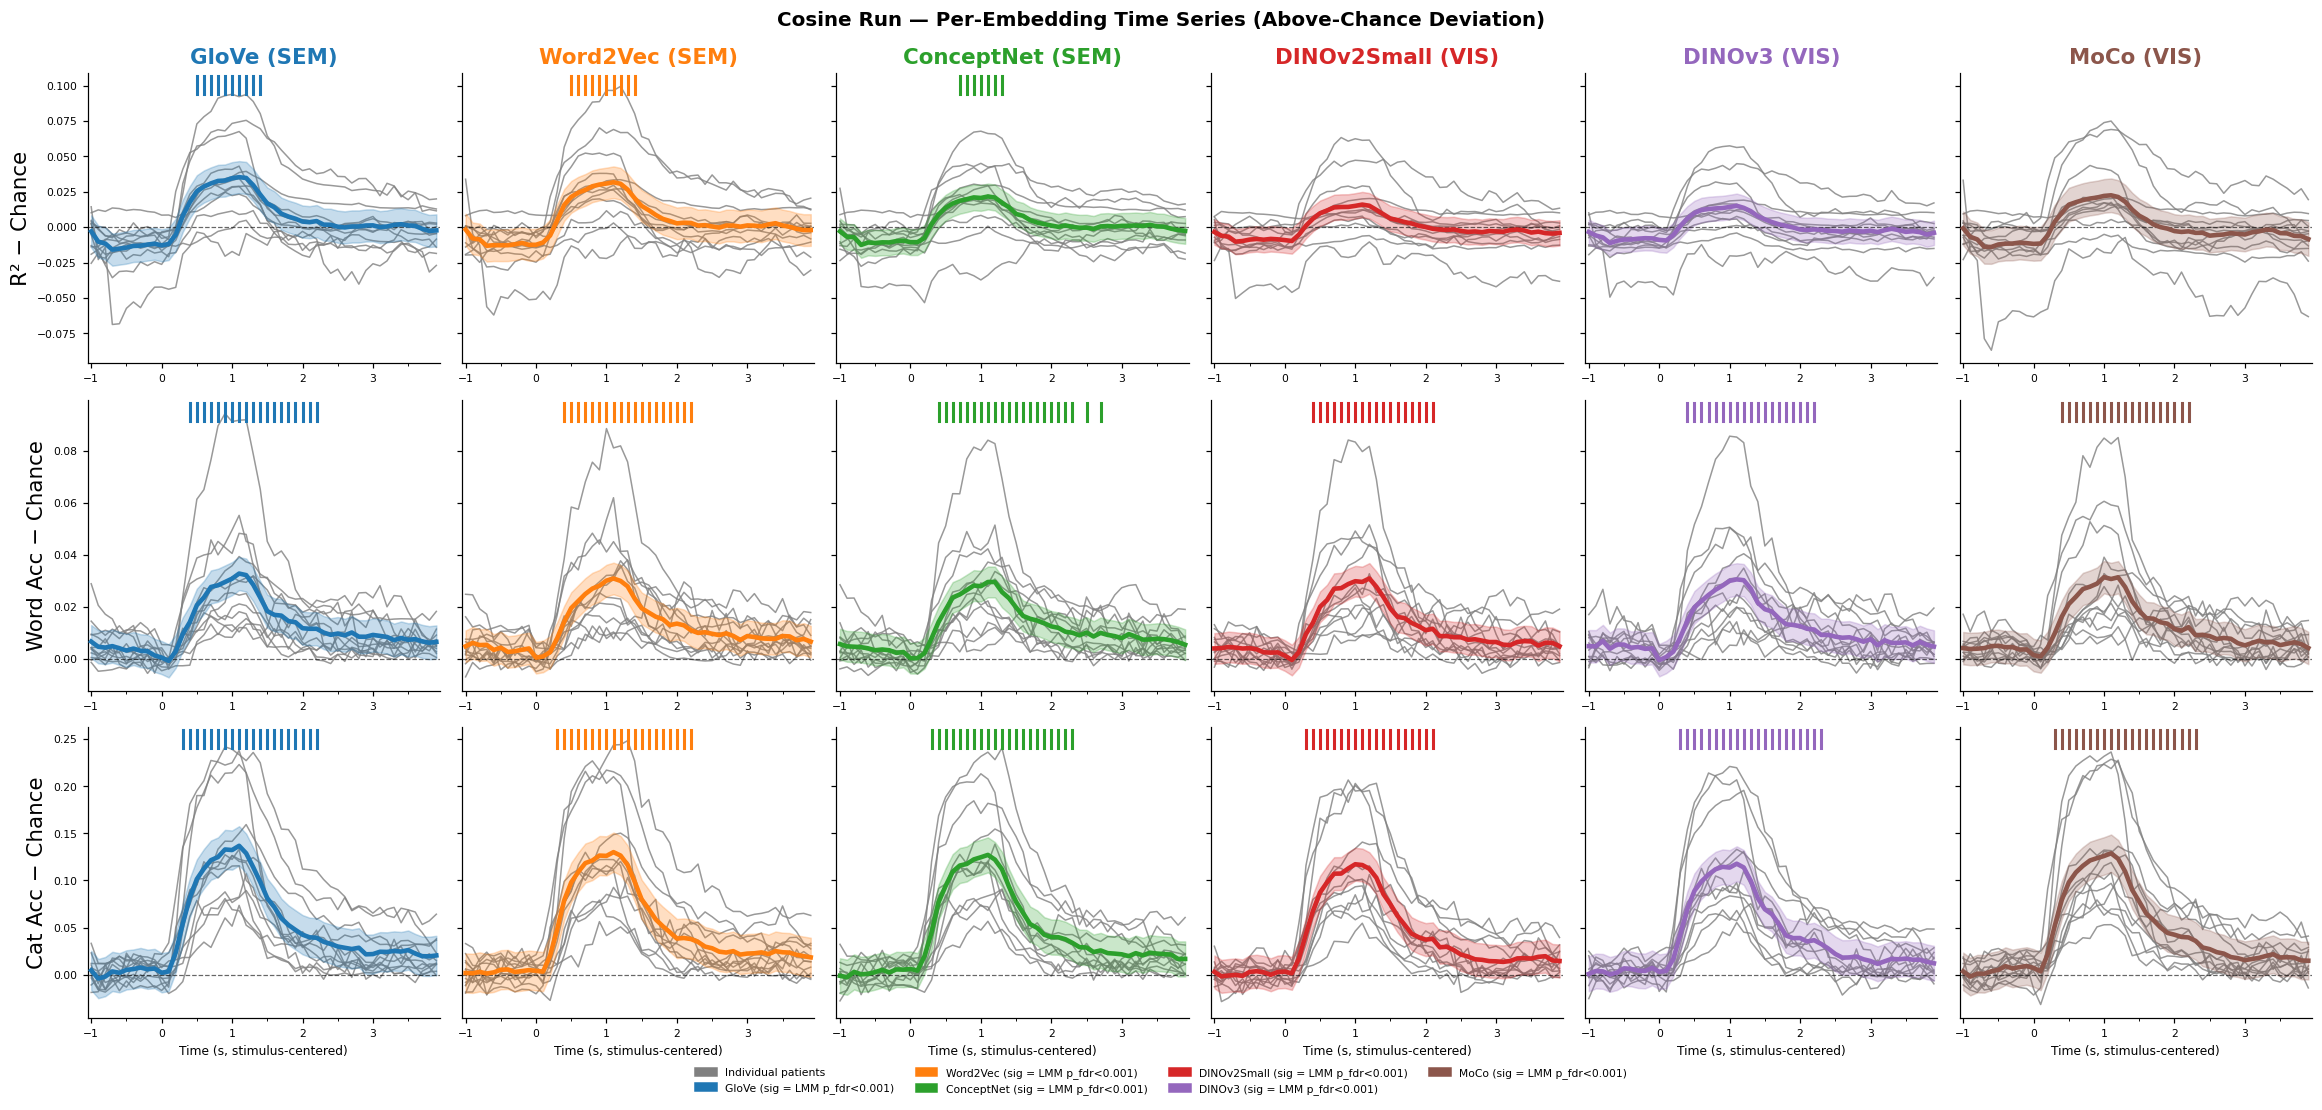

Saved: 04_per_embedding_timeseries.png


In [9]:
metric_labels = [
    ('r2',       'R² − Chance'),
    ('word',     'Word Acc − Chance'),
    ('category', 'Cat Acc − Chance'),
]
n_metrics = len(metric_labels)
n_embs    = len(embeddings)

PRE_STIM_MS = 1000
MS_PER_SEC = 1000.0
half_bin_s = (BIN_SIZE / 2) / MS_PER_SEC

fig, axes = plt.subplots(
    n_metrics, n_embs,
    figsize=(3.5 * n_embs, 3.2 * n_metrics),
    sharey='row',
    constrained_layout=True,
)
fig.suptitle('Cosine Run — Per-Embedding Time Series (Above-Chance Deviation)', fontsize=13, fontweight='bold')

time_vals_ms = np.array(sorted(df_pts['bin_index'].unique())) * BIN_SIZE
time_vals = (time_vals_ms - PRE_STIM_MS) / MS_PER_SEC

for row_idx, (metric_key, ylabel) in enumerate(metric_labels):
    per_patient = _get_per_patient_effect(df_pts, df_null, embeddings, metric_key)
    metric_sig  = sig_df[(sig_df['metric'] == metric_key)]

    for col_idx, emb in enumerate(embeddings):
        ax = axes[row_idx, col_idx]
        color = EMB_COLORS[emb]

        # Individual patient lines
        pat_data = per_patient.get(emb, {})
        for pat, eff in pat_data.items():
            t = time_vals[:len(eff)]
            ax.plot(t, eff, color='grey', alpha=0.8, lw=1, zorder=1)

        # Group estimated effect ± 95% CI from LMM
        lmm = metric_sig[metric_sig['embedding'] == emb].sort_values('bin_index')
        if len(lmm):
            lmm_t = (lmm['time_ms'].values - PRE_STIM_MS) / MS_PER_SEC
            ax.fill_between(lmm_t, lmm['ci_lower'].values, lmm['ci_upper'].values,
                            alpha=0.25, color=color, zorder=2)
            ax.plot(lmm_t, lmm['effect'].values, color=color, lw=3, zorder=3, label=emb)

        # Chance line
        ax.axhline(0, color='black', lw=0.8, ls='--', alpha=0.6)

        # Significance ticks at top
        emb_sig = metric_sig[(metric_sig['embedding'] == emb) & (metric_sig['significant'])]
        for t_sig in emb_sig['time_ms'].values:
            t_sig_s = (t_sig - PRE_STIM_MS) / MS_PER_SEC
            ax.axvline(t_sig_s, ymin=0.93, ymax=0.99, color=color, lw=2, zorder=5)

        ax.set_xlim(time_vals[0] - half_bin_s, time_vals[-1] + half_bin_s)
        ax.xaxis.set_major_locator(mticker.MultipleLocator(1.0))
        ax.xaxis.set_minor_locator(mticker.MultipleLocator(0.5))
        ax.tick_params(axis='x', labelsize=7)
        ax.tick_params(axis='y', labelsize=7)

        model_type = 'SEM' if emb in SEM_MODELS else 'VIS'
        if row_idx == 0:
            ax.set_title(f"{emb} ({model_type})", fontsize=14, fontweight='bold', color=color)
        if col_idx == 0:
            ax.set_ylabel(ylabel, fontsize=14)
        if row_idx == n_metrics - 1:
            ax.set_xlabel('Time (s, stimulus-centered)', fontsize=8)

        ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)

# Add significance legend
sig_patch = mpatches.Patch(color='grey', label='Individual patients')
fig.legend(
    handles=[sig_patch] + [
        mpatches.Patch(color=EMB_COLORS[e], label=f"{e} (sig = LMM p_fdr<{ALPHA})")
        for e in embeddings
    ],
    loc='lower center', ncol=4, fontsize=7, frameon=False,
    bbox_to_anchor=(0.5, -0.04)
)

plt.savefig(FIG_DIR / '04_per_embedding_timeseries.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: 04_per_embedding_timeseries.png")

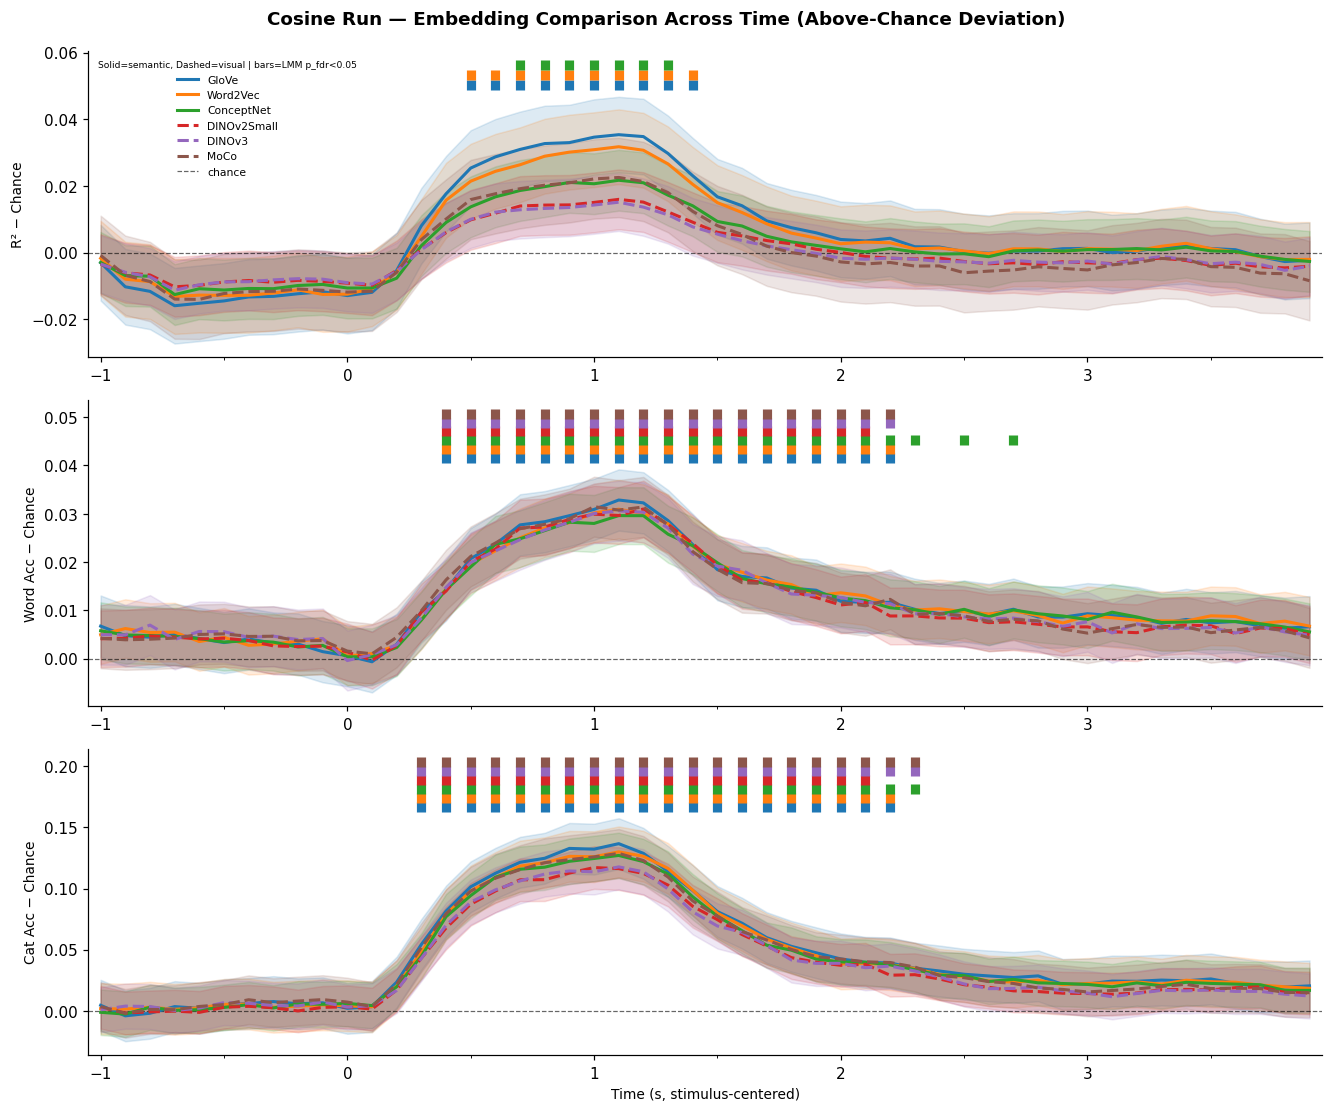

Saved: 05_embedding_comparison_overlay.png


In [10]:
PRE_STIM_MS = 1000
MS_PER_SEC = 1000.0
half_bin_s = (BIN_SIZE / 2) / MS_PER_SEC

fig, axes = plt.subplots(3, 1, figsize=(12, 10), constrained_layout=True)
fig.suptitle('Cosine Run — Embedding Comparison Across Time (Above-Chance Deviation)', fontsize=12, fontweight='bold')

for ax_idx, (metric_key, ylabel) in enumerate(metric_labels):
    ax = axes[ax_idx]
    metric_sig = sig_df[sig_df['metric'] == metric_key]

    # Determine significance bar y positions from LMM CI bounds
    y_max_data = metric_sig['ci_upper'].max() if len(metric_sig) else 0.1
    y_min_data = metric_sig['ci_lower'].min() if len(metric_sig) else -0.05
    y_range = y_max_data - y_min_data
    sig_bar_base = y_max_data + y_range * 0.05
    sig_bar_gap  = y_range * 0.04

    for i_emb, emb in enumerate(embeddings):
        color = EMB_COLORS[emb]
        lmm = metric_sig[metric_sig['embedding'] == emb].sort_values('bin_index')
        if not len(lmm):
            continue

        lmm_t = (lmm['time_ms'].values - PRE_STIM_MS) / MS_PER_SEC
        ax.fill_between(lmm_t, lmm['ci_lower'].values, lmm['ci_upper'].values,
                        alpha=0.15, color=color)
        ls = '-' if emb in SEM_MODELS else '--'
        ax.plot(lmm_t, lmm['effect'].values, color=color, lw=2, ls=ls, label=emb, zorder=3)

        # Significance bar (horizontal colored line at top)
        emb_sig = lmm[lmm['significant']]
        y_bar = sig_bar_base + i_emb * sig_bar_gap
        if len(emb_sig) > 0:
            sig_times_s = (emb_sig['time_ms'].values - PRE_STIM_MS) / MS_PER_SEC
            ax.scatter(
                sig_times_s,
                np.full(len(emb_sig), y_bar),
                color=color, marker='|', s=50, lw=6, zorder=4
            )

    ax.axhline(0, color='black', lw=0.8, ls='--', alpha=0.6, label='chance')
    ax.set_ylabel(ylabel, fontsize=9)
    ax.set_xlim(time_vals[0] - half_bin_s, time_vals[-1] + half_bin_s)
    ax.xaxis.set_major_locator(mticker.MultipleLocator(1.0))
    ax.xaxis.set_minor_locator(mticker.MultipleLocator(0.5))
    ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)

    if ax_idx == 2:
        ax.set_xlabel('Time (s, stimulus-centered)', fontsize=9)

    if ax_idx == 0:
        handles, labels = ax.get_legend_handles_labels()
        ax.legend(
            handles, labels,
            loc='upper left', fontsize=7, frameon=False,
            title='Solid=semantic, Dashed=visual | bars=LMM p_fdr<0.05',
            title_fontsize=6
        )

plt.savefig(FIG_DIR / '05_embedding_comparison_overlay.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: 05_embedding_comparison_overlay.png")

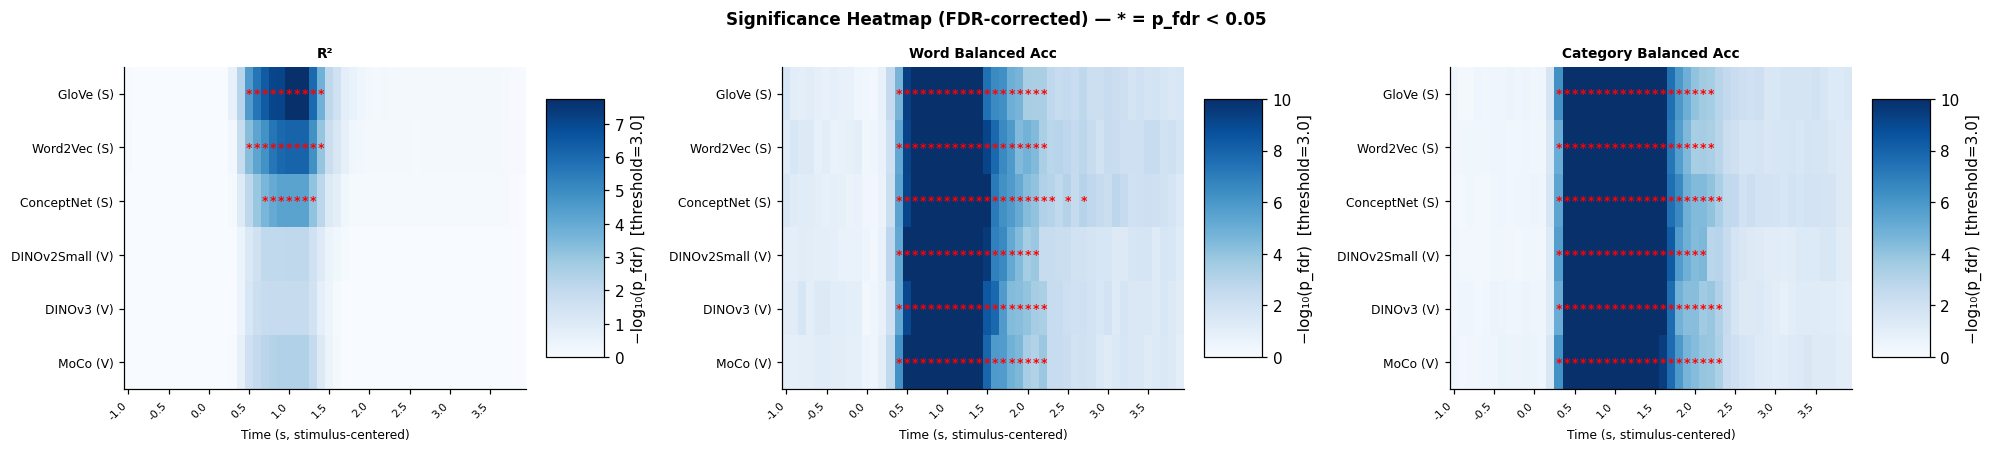

Saved: 06_significance_heatmap.png


In [11]:
def _sig_heatmap(ax, sig_df, metric_key, embeddings, title):
    sub = sig_df[sig_df['metric'] == metric_key]
    bins = sorted(sub['bin_index'].unique())
    n_emb = len(embeddings)
    n_bin = len(bins)

    PRE_STIM_MS = 1000
    MS_PER_SEC = 1000.0

    # Build matrix: rows=embeddings, cols=bins, value = -log10(p_fdr)
    mat = np.zeros((n_emb, n_bin))
    sig_mask = np.zeros((n_emb, n_bin), dtype=bool)
    for i, emb in enumerate(embeddings):
        for j, b in enumerate(bins):
            row = sub[(sub['embedding'] == emb) & (sub['bin_index'] == b)]
            if len(row):
                p = float(row['p_fdr'].values[0])
                mat[i, j] = -np.log10(max(p, 1e-10))
                sig_mask[i, j] = p < ALPHA

    vmax = max(mat.max(), -np.log10(ALPHA) + 0.5)
    im = ax.imshow(
        mat, aspect='auto', cmap='Blues',
        vmin=0, vmax=vmax,
        origin='upper',
    )

    # Star overlay for significant cells
    for i in range(n_emb):
        for j in range(n_bin):
            if sig_mask[i, j]:
                ax.text(j, i, '*', ha='center', va='center', fontsize=8, color='red', fontweight='bold')

    # Axis formatting
    ax.set_yticks(range(n_emb))
    ax.set_yticklabels([
        f"{e} ({'S' if e in SEM_MODELS else 'V'})"
        for e in embeddings
    ], fontsize=8)

    tick_step = max(1, n_bin // 10)
    ax.set_xticks(range(0, n_bin, tick_step))
    ax.set_xticklabels(
        [f"{((bins[j] * BIN_SIZE) - PRE_STIM_MS) / MS_PER_SEC:.1f}" for j in range(0, n_bin, tick_step)],
        fontsize=7, rotation=45, ha='right'
    )
    ax.set_xlabel('Time (s, stimulus-centered)', fontsize=8)
    ax.set_title(title, fontsize=9, fontweight='bold')

    # Threshold line
    thresh_val = -np.log10(ALPHA)
    plt.colorbar(im, ax=ax, label=f'−log₁₀(p_fdr)  [threshold={thresh_val:.1f}]', shrink=0.8)


fig, axes = plt.subplots(1, 3, figsize=(18, 4), constrained_layout=True)
fig.suptitle('Significance Heatmap (FDR-corrected) — * = p_fdr < 0.05', fontsize=11, fontweight='bold')

_sig_heatmap(axes[0], sig_df, 'r2',       embeddings, 'R²')
_sig_heatmap(axes[1], sig_df, 'word',     embeddings, 'Word Balanced Acc')
_sig_heatmap(axes[2], sig_df, 'category', embeddings, 'Category Balanced Acc')

plt.savefig(FIG_DIR / '06_significance_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: 06_significance_heatmap.png")

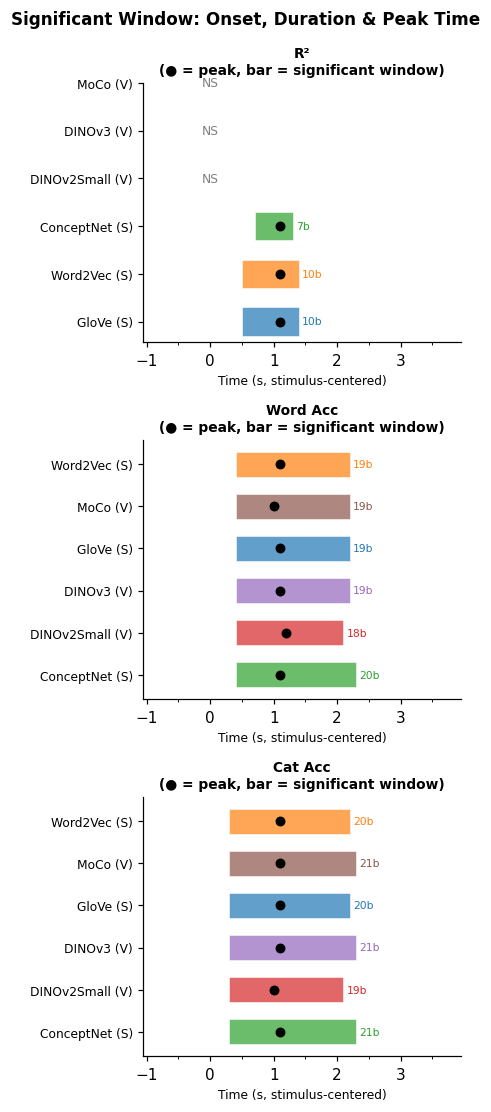

Saved: 07_sig_window_onset_duration.png


In [12]:
def get_longest_sig_run(sig_series, time_series):
    """
    Find the longest consecutive run of True values in sig_series.
    Returns (onset, offset, duration_bins) or (None, None, 0) if none.
    """
    best = (None, None, 0)
    run_start = None
    run_len = 0
    for t, s in zip(time_series, sig_series):
        if s:
            if run_start is None:
                run_start = t
            run_len += 1
            run_end = t
        else:
            if run_len > best[2]:
                best = (run_start, run_end, run_len)
            run_start = None
            run_len = 0
    if run_len > best[2]:
        best = (run_start, run_end, run_len)
    return best


PRE_STIM_MS = 1000
MS_PER_SEC = 1000.0
half_bin_s = (BIN_SIZE / 2) / MS_PER_SEC

summary_rows = []
for (emb, metric), grp in sig_df.groupby(['embedding', 'metric']):
    grp = grp.sort_values('bin_index')
    peak_idx = grp['effect'].idxmax()
    peak_ms  = grp.loc[peak_idx, 'time_ms']
    onset, offset, n_bins = get_longest_sig_run(
        grp['significant'].values,
        grp['time_ms'].values
    )
    summary_rows.append({
        'embedding':     emb,
        'metric':        metric,
        'onset_ms':      onset,
        'offset_ms':     offset,
        'n_sig_bins':    n_bins,
        'peak_ms':       peak_ms,
        'peak_effect':   float(grp.loc[peak_idx, 'effect']),
        'peak_se':       float(grp.loc[peak_idx, 'se']),
        'peak_ci_lower': float(grp.loc[peak_idx, 'ci_lower']),
        'peak_ci_upper': float(grp.loc[peak_idx, 'ci_upper']),
        'peak_obs':      float(grp.loc[peak_idx, 'mean_obs']),
        'peak_null':     float(grp.loc[peak_idx, 'mean_null']),
        'peak_sem':      float(grp.loc[peak_idx, 'sem_obs']),
        'tau2':          float(grp['tau2'].iloc[0]),
    })
summary_df = pd.DataFrame(summary_rows)

# ── Figure 4 ────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(3, 1, figsize=(4, 10), constrained_layout=True)
fig.suptitle('Significant Window: Onset, Duration & Peak Time', fontsize=11, fontweight='bold')

time_vals_s = (np.array(sorted(df_pts['bin_index'].unique())) * BIN_SIZE - PRE_STIM_MS) / MS_PER_SEC

for ax_idx, metric_key in enumerate(['r2', 'word', 'category']):
    ax = axes[ax_idx]
    msub = summary_df[summary_df['metric'] == metric_key].copy()

    # Convert trial-relative ms to stimulus-centered seconds for plotting
    msub['onset_s']  = (msub['onset_ms'] - PRE_STIM_MS) / MS_PER_SEC
    msub['offset_s'] = (msub['offset_ms'] - PRE_STIM_MS) / MS_PER_SEC
    msub['peak_s']   = (msub['peak_ms'] - PRE_STIM_MS) / MS_PER_SEC

    # Sort by onset (None -> place at end)
    msub['_sort'] = msub['onset_s'].fillna(9999)
    msub = msub.sort_values('_sort')

    y_positions = range(len(msub))
    for y_pos, (_, row) in zip(y_positions, msub.iterrows()):
        emb   = row['embedding']
        color = EMB_COLORS[emb]
        onset  = row['onset_s']
        offset = row['offset_s']

        if pd.notna(onset) and pd.notna(offset):
            # Draw horizontal significance span
            ax.barh(
                y_pos, offset - onset, left=onset,
                height=0.6, color=color, alpha=0.7, edgecolor='white', lw=0.5
            )
            # Peak marker
            ax.scatter(row['peak_s'], y_pos, color='black', s=30, zorder=5)
            # Duration label
            ax.text(
                offset + 0.05, y_pos, f"{row['n_sig_bins']}b",
                va='center', fontsize=7, color=color
            )
        else:
            ax.text(0.0, y_pos, 'NS', va='center', ha='center', fontsize=8, color='grey')

    metric_titles = {'r2': 'R²', 'word': 'Word Acc', 'category': 'Cat Acc'}
    ax.set_yticks(list(y_positions))
    ax.set_yticklabels(
        [f"{r['embedding']} ({'S' if r['embedding'] in SEM_MODELS else 'V'})" for _, r in msub.iterrows()],
        fontsize=8
    )
    ax.set_xlabel('Time (s, stimulus-centered)', fontsize=8)
    ax.set_title(f"{metric_titles[metric_key]}\n(● = peak, bar = significant window)", fontsize=9, fontweight='bold')
    ax.set_xlim(time_vals_s[0] - half_bin_s, time_vals_s[-1] + half_bin_s)
    ax.xaxis.set_major_locator(mticker.MultipleLocator(1.0))
    ax.xaxis.set_minor_locator(mticker.MultipleLocator(0.5))
    ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)

plt.savefig(FIG_DIR / '07_sig_window_onset_duration.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: 07_sig_window_onset_duration.png")

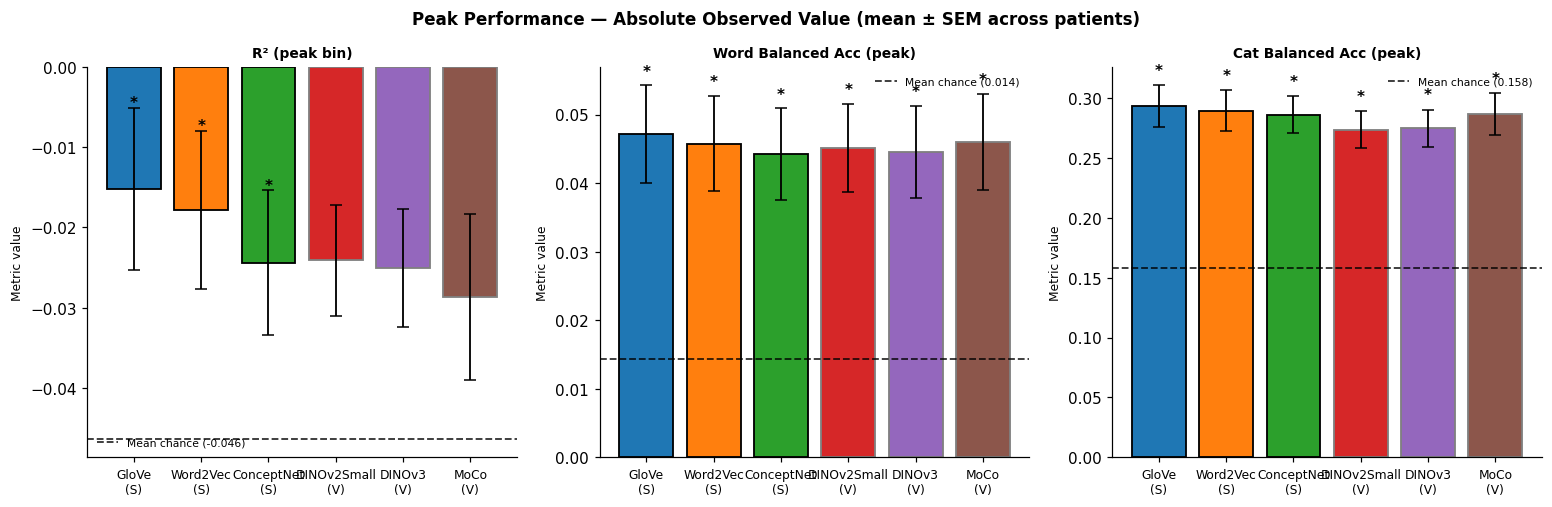

Saved: 08_peak_performance.png


In [13]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4.5), constrained_layout=True)
fig.suptitle('Peak Performance — Absolute Observed Value (mean ± SEM across patients)', fontsize=11, fontweight='bold')

metric_titles = {'r2': 'R² (peak bin)', 'word': 'Word Balanced Acc (peak)', 'category': 'Cat Balanced Acc (peak)'}

for ax_idx, metric_key in enumerate(['r2', 'word', 'category']):
    ax = axes[ax_idx]
    msub = summary_df[summary_df['metric'] == metric_key].copy()

    x = np.arange(len(embeddings))
    bar_colors = [EMB_COLORS[e] for e in embeddings]
    edge_colors = ['black' if e in SEM_MODELS else 'grey' for e in embeddings]

    peak_vals  = []
    peak_sems  = []
    null_vals  = []

    for emb in embeddings:
        row = msub[msub['embedding'] == emb]
        if len(row):
            peak_vals.append(row['peak_obs'].values[0])
            peak_sems.append(row['peak_sem'].values[0])
            null_vals.append(row['peak_null'].values[0])
        else:
            peak_vals.append(0)
            peak_sems.append(0)
            null_vals.append(0)

    bars = ax.bar(
        x, peak_vals, color=bar_colors, edgecolor=edge_colors,
        linewidth=1.2, yerr=peak_sems, capsize=4,
        error_kw={'ecolor': 'black', 'elinewidth': 1.2}
    )

    # Chance level (mean across embeddings at that bin)
    mean_chance = np.mean(null_vals)
    ax.axhline(mean_chance, color='black', lw=1.2, ls='--', alpha=0.8, label=f'Mean chance ({mean_chance:.3f})')

    # Significance stars above bars
    for i, emb in enumerate(embeddings):
        emb_sig = sig_df[
            (sig_df['embedding'] == emb) &
            (sig_df['metric'] == metric_key) &
            (sig_df['significant'])
        ]
        if len(emb_sig) > 0:
            ax.text(
                i, peak_vals[i] + peak_sems[i] + (max(peak_vals) * 0.02),
                '*', ha='center', va='bottom', fontsize=10, fontweight='bold'
            )

    ax.set_xticks(x)
    ax.set_xticklabels(
        [f"{e}\n({'S' if e in SEM_MODELS else 'V'})" for e in embeddings],
        fontsize=8
    )
    ax.set_title(metric_titles[metric_key], fontsize=9, fontweight='bold')
    ax.legend(fontsize=7, frameon=False)
    ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
    ax.set_ylabel('Metric value', fontsize=8)

plt.savefig(FIG_DIR / '08_peak_performance.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: 08_peak_performance.png")

In [14]:
print('Note: Figures use stimulus-centered seconds (0 s = stimulus onset); this table remains trial-relative milliseconds.')
print('Statistical method: Linear mixed-effects model with random intercept per patient.\n')

table = summary_df[[
    'embedding', 'metric',
    'peak_effect', 'peak_ci_lower', 'peak_ci_upper', 'peak_ms',
    'onset_ms', 'offset_ms', 'n_sig_bins', 'tau2'
]].copy()

table.columns = [
    'Embedding', 'Metric',
    'Peak Effect', 'CI Lower', 'CI Upper', 'Peak Time (ms)',
    'Onset (ms)', 'Offset (ms)', 'N Sig Bins', 'τ²'
]

# Add model type
table.insert(1, 'Type', table['Embedding'].apply(lambda e: 'Semantic' if e in SEM_MODELS else 'Visual'))

# Format floats
for col in ['Peak Effect', 'CI Lower', 'CI Upper', 'τ²']:
    table[col] = table[col].round(4)

# Pivot for compact display
for metric_key in ['r2', 'word', 'category']:
    metric_label = {'r2': 'R²', 'word': 'Word Acc', 'category': 'Cat Acc'}[metric_key]
    sub = table[table['Metric'] == metric_key].drop(columns='Metric')
    print(f"\n── {metric_label} ──")

    # Highlight best per numeric column
    numeric_cols = sub.select_dtypes(include='number').columns
    styled = sub.style.highlight_max(subset=[c for c in numeric_cols if c in ['Peak Effect', 'N Sig Bins']], color='#c6f7c6') \
                      .highlight_min(subset=[c for c in numeric_cols if c == 'Onset (ms)'], color='#c6f7c6') \
                      .format(na_rep='—', precision=4)
    display(styled)

# Save full table
table.to_csv(SRC_DIR / 'summary_table.csv', index=False)
print("\nSaved: summary_table.csv")

Note: Figures use stimulus-centered seconds (0 s = stimulus onset); this table remains trial-relative milliseconds.
Statistical method: Linear mixed-effects model with random intercept per patient.


── R² ──


,Embedding,Type,Peak Effect,CI Lower,CI Upper,Peak Time (ms),Onset (ms),Offset (ms),N Sig Bins,τ²
1,ConceptNet,Semantic,0.0217,0.0126,0.0308,2100,1700.0000,2300.0000,7,0.0002
4,DINOv2Small,Visual,0.0160,0.0070,0.0249,2100,—,—,0,0.0002
7,DINOv3,Visual,0.0151,0.0065,0.0237,2100,—,—,0,0.0002
10,GloVe,Semantic,0.0354,0.0240,0.0467,2100,1500.0000,2400.0000,10,0.0003
13,MoCo,Visual,0.0225,0.0106,0.0344,2100,—,—,0,0.0003
16,Word2Vec,Semantic,0.0318,0.0205,0.0430,2100,1500.0000,2400.0000,10,0.0003



── Word Acc ──


,Embedding,Type,Peak Effect,CI Lower,CI Upper,Peak Time (ms),Onset (ms),Offset (ms),N Sig Bins,τ²
2,ConceptNet,Semantic,0.0296,0.0237,0.0355,2100,1400.0000,3300.0000,20,0.0000
5,DINOv2Small,Visual,0.0310,0.0251,0.0369,2200,1400.0000,3100.0000,18,0.0000
8,DINOv3,Visual,0.0306,0.0244,0.0368,2100,1400.0000,3200.0000,19,0.0000
11,GloVe,Semantic,0.0328,0.0265,0.0392,2100,1400.0000,3200.0000,19,0.0001
14,MoCo,Visual,0.0315,0.0252,0.0377,2000,1400.0000,3200.0000,19,0.0000
17,Word2Vec,Semantic,0.0309,0.0249,0.0370,2100,1400.0000,3200.0000,19,0.0000



── Cat Acc ──


,Embedding,Type,Peak Effect,CI Lower,CI Upper,Peak Time (ms),Onset (ms),Offset (ms),N Sig Bins,τ²
0,ConceptNet,Semantic,0.1271,0.1085,0.1457,2100,1300.0000,3300.0000,21,0.0005
3,DINOv2Small,Visual,0.1172,0.0997,0.1346,2000,1300.0000,3100.0000,19,0.0004
6,DINOv3,Visual,0.1177,0.0993,0.1362,2100,1300.0000,3300.0000,21,0.0005
9,GloVe,Semantic,0.1367,0.1159,0.1575,2100,1300.0000,3200.0000,20,0.0007
12,MoCo,Visual,0.1288,0.1088,0.1487,2100,1300.0000,3300.0000,21,0.0006
15,Word2Vec,Semantic,0.1300,0.1093,0.1508,2100,1300.0000,3200.0000,20,0.0007



Saved: summary_table.csv


In [15]:
from itertools import combinations
ALPHA=0.025
def compute_pairwise_significance(sig_df, df_null, df_pts, embeddings, compare_pairs=None):
    """
    Test whether embedding A's above-chance effect is significantly larger than
    embedding B's at each time bin, using an LMM.

    For each (A, B) pair and metric:
        diff[patient, bin] = effect_A[patient,bin] - effect_B[patient,bin]
    Fits: diff ~ 0 + C(bin_index), groups=patient
    One-sided H1: diff > 0  (A > B). FDR across bins per (pair, metric).

    Parameters
    ----------
    sig_df       : output of compute_group_significance — used to pull per-patient effects
    df_null      : cache DataFrame with cat/word per-patient means
    df_pts       : per_time_scores DataFrame (for R²)
    embeddings   : list of embedding names
    compare_pairs: list of (A, B) tuples, or None for all pairwise

    Returns
    -------
    pair_df : pd.DataFrame with one row per (pair, bin, metric)
    """
    if compare_pairs is None:
        compare_pairs = list(combinations(embeddings, 2))

    # Build per-patient per-bin effects for each embedding and metric
    def _patient_effects(emb, metric):
        """Return dict[patient] -> array(n_bins) of per-patient mean effects."""
        if metric == 'r2':
            sub = df_pts[df_pts['embedding'] == emb].sort_values(['patient', 'bin_index'])
            out = {}
            for pat, g in sub.groupby('patient'):
                g = g.sort_values('bin_index')
                out[pat] = (g['r2_mean'].values - g['chance_mean'].values)
        elif metric == 'cosine':
            # No chance cosine is stored, and raw cosine is offset by each embedding
            # space's anisotropy. Subtract each patient/embedding's own pre-stimulus
            # mean (bins before onset = no-information floor) so the A-vs-B difference
            # reflects task-driven fit, not space geometry.
            PRE_STIM_BINS = 10  # 1000 ms baseline / 100 ms bin
            sub = df_pts[df_pts['embedding'] == emb].sort_values(['patient', 'bin_index'])
            out = {}
            for pat, g in sub.groupby('patient'):
                g = g.sort_values('bin_index')
                cos = g['cosine_mean'].values
                base = cos[:PRE_STIM_BINS].mean() if len(cos) >= PRE_STIM_BINS else cos.mean()
                out[pat] = cos - base
        elif metric == 'word':
            sub = df_null[df_null['embedding'] == emb].sort_values(['patient', 'bin_index'])
            out = {}
            for pat, g in sub.groupby('patient'):
                g = g.sort_values('bin_index')
                out[pat] = (g['word_obs_mean'].values - g['word_null_mean'].values)
        else:  # category
            sub = df_null[df_null['embedding'] == emb].sort_values(['patient', 'bin_index'])
            out = {}
            for pat, g in sub.groupby('patient'):
                g = g.sort_values('bin_index')
                out[pat] = (g['cat_obs_mean'].values - g['cat_null_mean'].values)
        return out

    metrics = ['r2', 'cosine', 'word', 'category']
    records = []

    for (emb_a, emb_b) in compare_pairs:
        if emb_a not in embeddings or emb_b not in embeddings:
            print(f"  [skip] {emb_a} or {emb_b} not in embeddings")
            continue

        for metric in metrics:
            eff_a = _patient_effects(emb_a, metric)
            eff_b = _patient_effects(emb_b, metric)
            patients_both = sorted(set(eff_a.keys()) & set(eff_b.keys()))

            if len(patients_both) < 3:
                print(f"  [skip] {emb_a} vs {emb_b} / {metric}: too few patients")
                continue

            # Build long-form diff table
            rows = []
            for pat in patients_both:
                a_arr = eff_a[pat]
                b_arr = eff_b[pat]
                n_bins = min(len(a_arr), len(b_arr))
                for b in range(n_bins):
                    rows.append({'patient': pat, 'bin_index': b, 'diff': float(a_arr[b] - b_arr[b])})
            long = pd.DataFrame(rows)

            # Fit LMM
            try:
                model = smf.mixedlm("diff ~ 0 + C(bin_index)", data=long, groups=long["patient"])
                result = model.fit(reml=True)
                ci_df = result.conf_int()
                tau2 = float(result.cov_re.iloc[0, 0])
            except Exception as e:
                raise RuntimeError(f"LMM failed {emb_a} vs {emb_b}/{metric}: {e}")

            bin_records = []
            for param_name in result.fe_params.index:
                b_str = param_name.rsplit('[', 1)[1].rstrip(']')
                if b_str.startswith('T.'):
                    b_str = b_str[2:]
                b = int(float(b_str))
                estimate = float(result.fe_params[param_name])
                se = float(result.bse[param_name])
                p_two = float(result.pvalues[param_name])
                p_one = p_two / 2 if estimate > 0 else 1.0 - p_two / 2
                ci_lo = float(ci_df.loc[param_name].iloc[0])
                ci_hi = float(ci_df.loc[param_name].iloc[1])
                bin_records.append({
                    'pair':      f"{emb_a} > {emb_b}",
                    'emb_a':     emb_a,
                    'emb_b':     emb_b,
                    'bin_index': b,
                    'time_ms':   b * BIN_SIZE,
                    'metric':    metric,
                    'diff':      estimate,
                    'se':        se,
                    'ci_lower':  ci_lo,
                    'ci_upper':  ci_hi,
                    'n_patients': len(patients_both),
                    'p_raw':     p_one,
                    'tau2':      tau2,
                    'method':    'lmm',
                })
            records.extend(bin_records)

    if not records:
        return pd.DataFrame()

    df = pd.DataFrame(records)


    # FDR per (pair, metric)
    fdr_parts = []
    for (pair, metric), grp in df.groupby(['pair', 'metric']):
        p_vals = grp['p_raw'].values
        _, fdr, _, _ = multipletests(p_vals, alpha=ALPHA, method='fdr_bh')
        grp = grp.copy()
        grp['p_fdr'] = fdr
        fdr_parts.append(grp)

    df = pd.concat(fdr_parts, ignore_index=True)
    df['significant'] = df['p_fdr'] < ALPHA
    return df.sort_values(['pair', 'metric', 'bin_index']).reset_index(drop=True)


# ── Compute ──────────────────────────────────────────────────────────────────
pair_df = compute_pairwise_significance(sig_df, df_null, df_pts, embeddings, COMPARE_PAIRS)
print(f"pair_df shape: {pair_df.shape}")
if len(pair_df):
    n_sig_pair = pair_df['significant'].sum()
    print(f"Significant (p_fdr < {ALPHA}): {n_sig_pair}/{len(pair_df)}")
    print(f"Methods used: {pair_df['method'].value_counts().to_dict()}")
    print()
    print(pair_df.groupby(['pair', 'metric'])['significant'].sum().unstack('metric'))


pair_df shape: (1200, 16)
Significant (p_fdr < 0.025): 371/1200
Methods used: {'lmm': 1200}

metric                  category  cosine  r2  word
pair                                              
GloVe > DINOv2Small           21      38  16     0
GloVe > DINOv3                21      38  20     0
GloVe > MoCo                   0      36  30     0
Word2Vec > DINOv2Small        10      37  13     0
Word2Vec > DINOv3              9      37  14     0
Word2Vec > MoCo                0       0  31     0


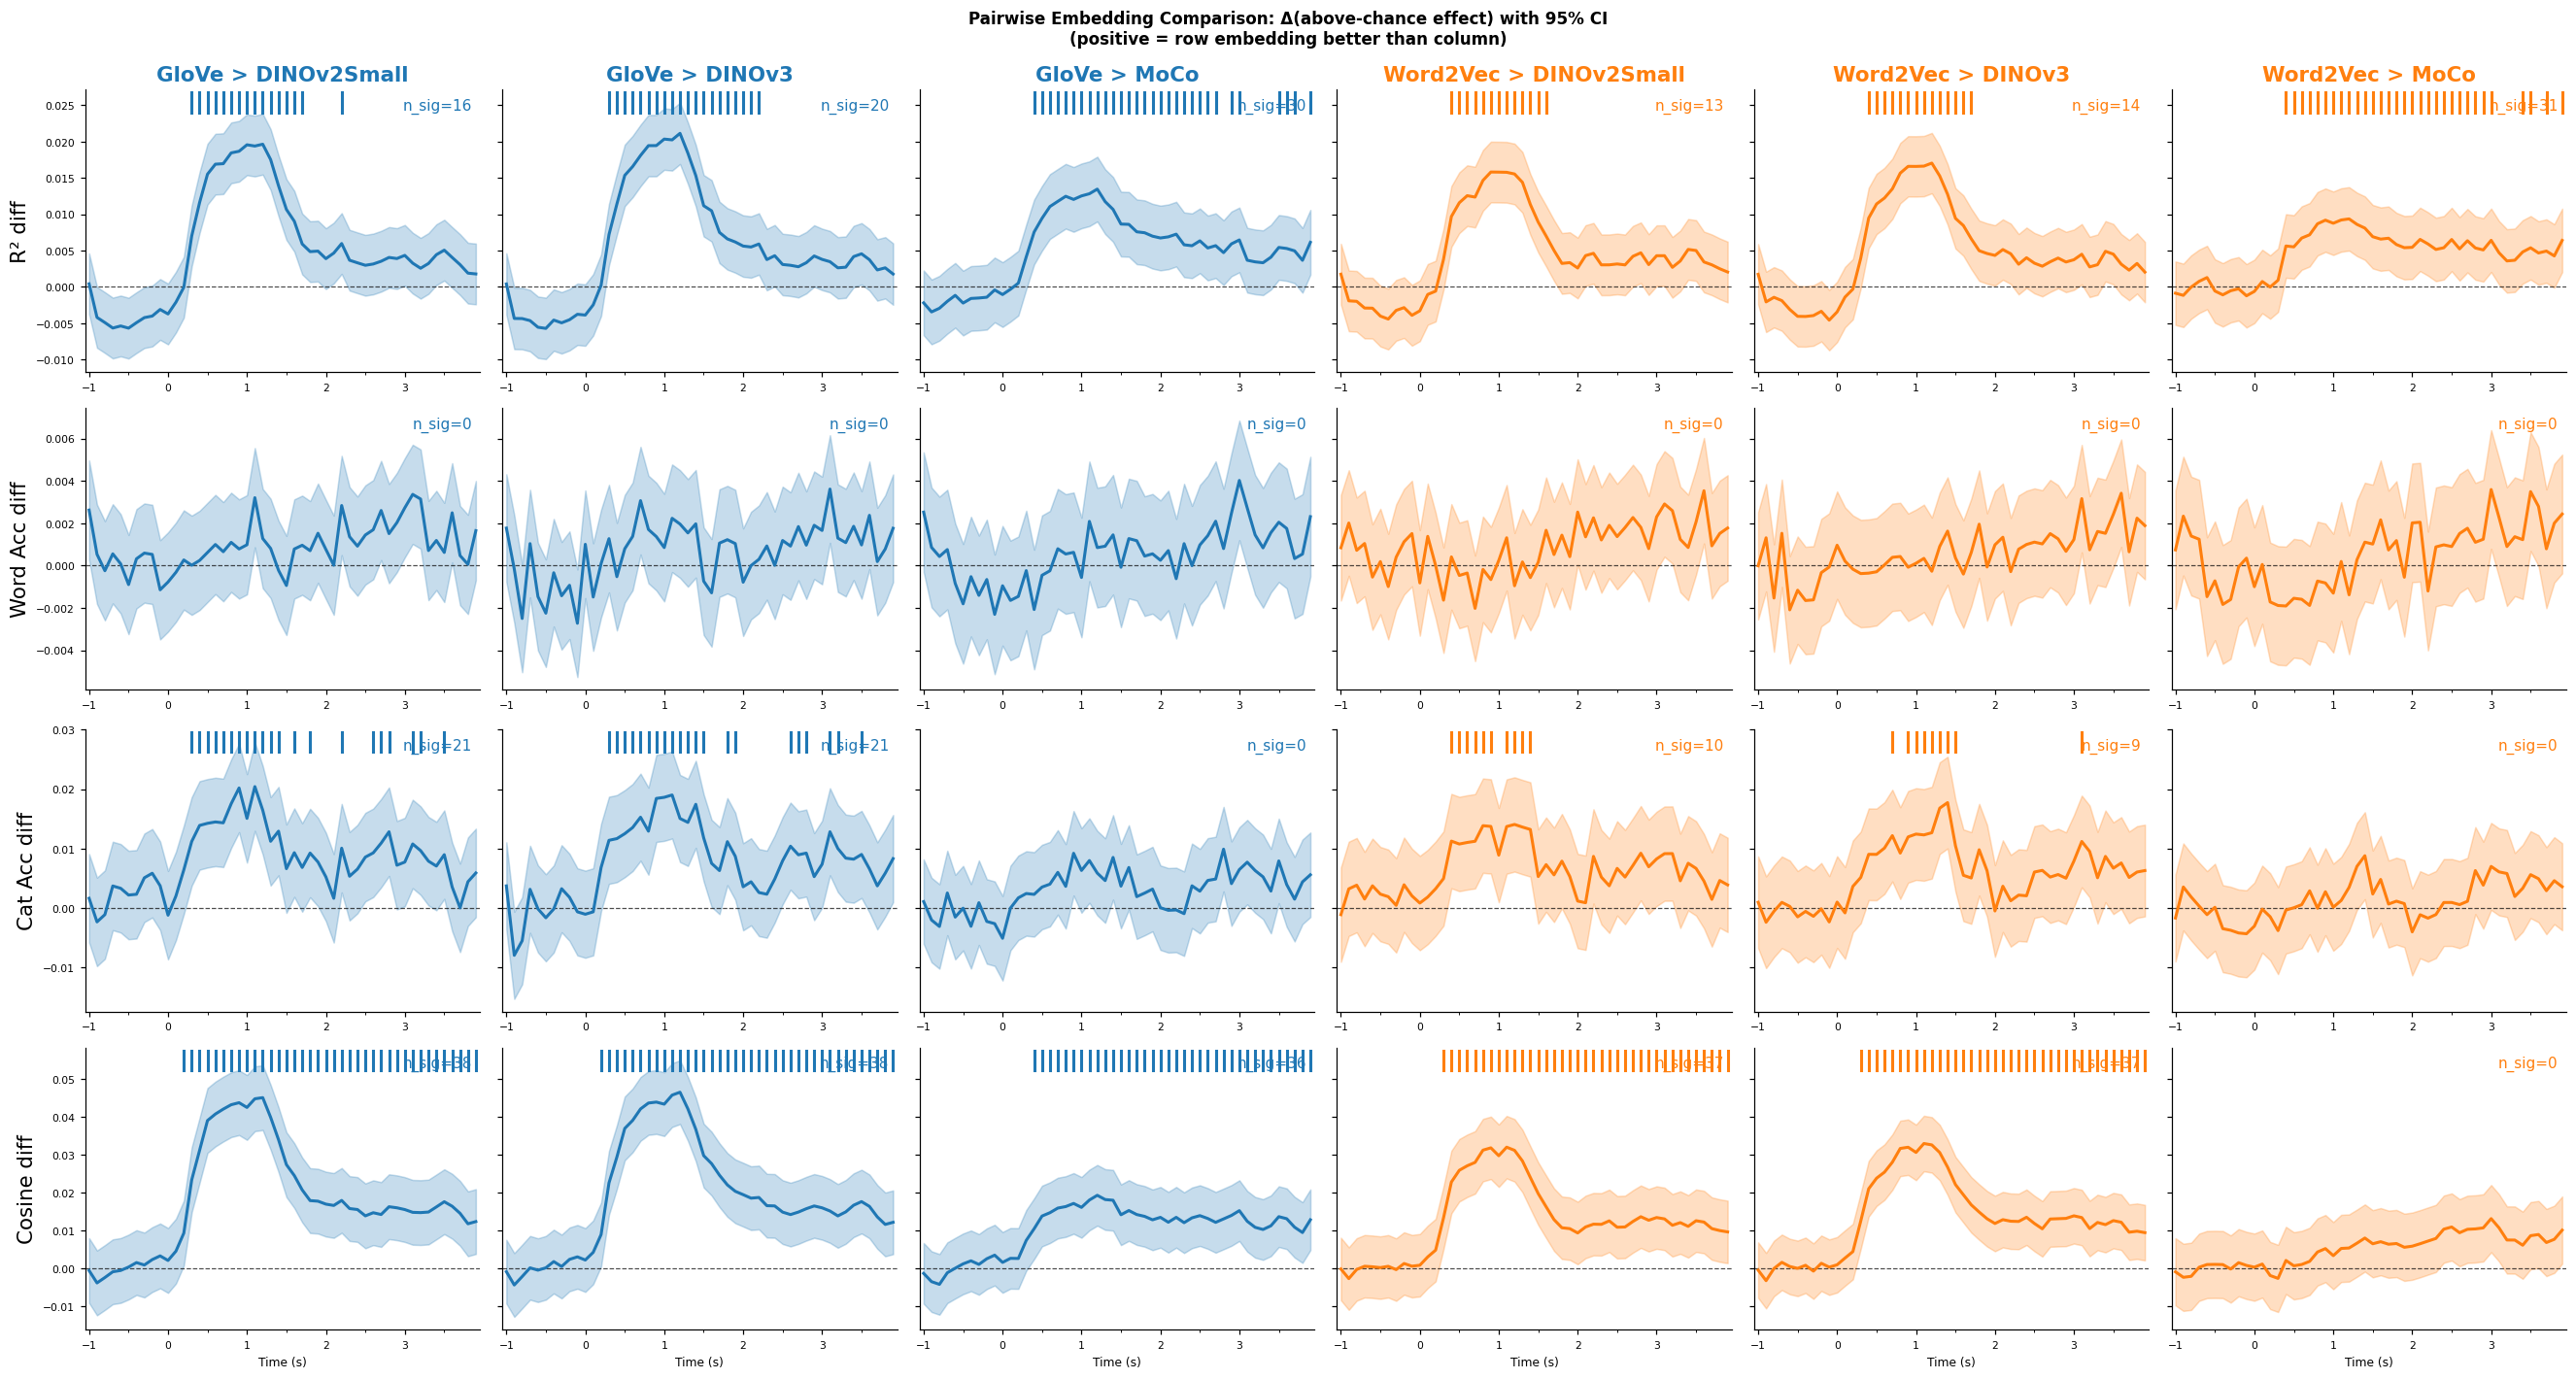

Saved: 09_pairwise_comparison.png


In [16]:
if len(pair_df) == 0:
    print("No pairwise results to plot. Check COMPARE_PAIRS.")
else:
    PRE_STIM_MS = 1000
    MS_PER_SEC = 1000.0
    half_bin_s = (BIN_SIZE / 2) / MS_PER_SEC

    pairs = pair_df['pair'].unique()
    metric_list = [('r2', 'R² diff'), ('word', 'Word Acc diff'), ('category', 'Cat Acc diff'), ('cosine', 'Cosine diff')]
    n_pairs = len(pairs)
    n_met = len(metric_list)

    fig, axes = plt.subplots(
        n_met, n_pairs,
        figsize=(4.0 * n_pairs, 3.2 * n_met),
        sharey='row',
        constrained_layout=True,
    )
    # Ensure axes is always 2-D
    if n_pairs == 1:
        axes = axes[:, np.newaxis]
    if n_met == 1:
        axes = axes[np.newaxis, :]

    fig.suptitle('Pairwise Embedding Comparison: Δ(above-chance effect) with 95% CI\n'
                 '(positive = row embedding better than column)', fontsize=11, fontweight='bold')

    for col_idx, pair_label in enumerate(pairs):
        sub = pair_df[pair_df['pair'] == pair_label]
        emb_a = sub['emb_a'].iloc[0]
        emb_b = sub['emb_b'].iloc[0]
        color_a = EMB_COLORS.get(emb_a, 'steelblue')

        for row_idx, (metric_key, ylabel) in enumerate(metric_list):
            ax = axes[row_idx, col_idx]
            m = sub[sub['metric'] == metric_key].sort_values('bin_index')

            if not len(m):
                ax.set_visible(False)
                continue

            t_s = (m['time_ms'].values - PRE_STIM_MS) / MS_PER_SEC

            # CI band
            ax.fill_between(t_s, m['ci_lower'].values, m['ci_upper'].values,
                            alpha=0.25, color=color_a)
            # Difference line
            ax.plot(t_s, m['diff'].values, color=color_a, lw=2, zorder=3)
            # Zero reference
            ax.axhline(0, color='black', lw=0.8, ls='--', alpha=0.7)

            # Significance ticks (A > B, p_fdr < ALPHA)
            sig_mask = m['significant'].values
            for t_sig in m.loc[m['significant'], 'time_ms'].values:
                ax.axvline((t_sig - PRE_STIM_MS) / MS_PER_SEC,
                           ymin=0.92, ymax=0.99, color=color_a, lw=2, zorder=5)

            ax.set_xlim(t_s[0] - half_bin_s, t_s[-1] + half_bin_s)
            ax.xaxis.set_major_locator(mticker.MultipleLocator(1.0))
            ax.xaxis.set_minor_locator(mticker.MultipleLocator(0.5))
            ax.tick_params(axis='x', labelsize=7)
            ax.tick_params(axis='y', labelsize=7)
            ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)

            if row_idx == 0:
                ax.set_title(pair_label, fontsize=14, fontweight='bold', color=color_a)
            if col_idx == 0:
                ax.set_ylabel(ylabel, fontsize=14)
            if row_idx == n_met - 1:
                ax.set_xlabel('Time (s)', fontsize=8)

            # Annotate n sig bins
            n_sig_b = sig_mask.sum()
            ax.text(0.98, 0.97, f'n_sig={n_sig_b}',
                    transform=ax.transAxes, ha='right', va='top', fontsize=10, color=color_a)

    plt.savefig(FIG_DIR / '09_pairwise_comparison.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("Saved: 09_pairwise_comparison.png")


---
---
## Section 2 — Kernel-PLS: language vs vision embedding models

**Question:** When a Kernel PLS model is trained to regress iEEG activity onto
embedding space, which embedding family achieves higher category and word retrieval?

**Prediction:** Language models (GloVe, FastText, Word2Vec, ConceptNet) > vision
models (DINOv2, SimCLR) on `cat_bal_acc` and `word_bal_acc`.

*Source: `tests/model_diagnostics/regression_model_comparison.py` →
`tests/results/model_comparison_{patient}.csv`*

> **Available patients:** AA, RB, VB  
> **Model shown:** Kernel PLS (Nystroem-RBF → PLSRegression) — best-performing model variant

In [17]:
# ── 3a. Load and combine model-comparison CSVs ────────────────────────────
mc_files  = sorted(TESTS_RESULTS_DIR.glob('model_comparison_*.csv'))
mc_frames = []
for f in mc_files:
    df_f = pd.read_csv(f)
    mc_frames.append(df_f)

if not mc_frames:
    raise FileNotFoundError('No model_comparison_*.csv files found in ' + str(TESTS_RESULTS_DIR))

mc_all = pd.concat(mc_frames, ignore_index=True)
print('Patients in model comparison:', sorted(mc_all['patient'].unique()))
print('Models:', sorted(mc_all['model'].unique()))
print('Embeddings:', sorted(mc_all['embedding'].unique()))
mc_all.head(3)

Patients in model comparison: ['AA', 'RB', 'VB']
Models: ['kernel_pls', 'krr', 'linear_ridge', 'pls']
Embeddings: ['ConceptNet', 'DINOv2', 'FastText', 'GloVe', 'SimCLR', 'Word2Vec']


,patient,model,model_label,nonlinear,embedding,test_r2,chance_r2,delta_r2,cat_bal_acc,word_bal_acc,pred_entropy_norm,top1_word,top1_frac,cat_best_bin,word_best_bin,r2_best_bin,test_cosine,train_cosine
0,AA,linear_ridge,A: Linear Ridge,False,GloVe,-0.232258,-0.373260,0.141002,0.395094,0.058324,0.938194,bat(animal),0.066667,21,22,20,NaN,NaN
1,AA,linear_ridge,A: Linear Ridge,False,FastText,-0.315661,-0.417629,0.101969,0.356835,0.050466,0.940659,bat(animal),0.094118,20,19,19,NaN,NaN
2,AA,linear_ridge,A: Linear Ridge,False,Word2Vec,-0.270397,-0.386000,0.115604,0.383896,0.057232,0.947575,bat(animal),0.066667,20,21,20,NaN,NaN


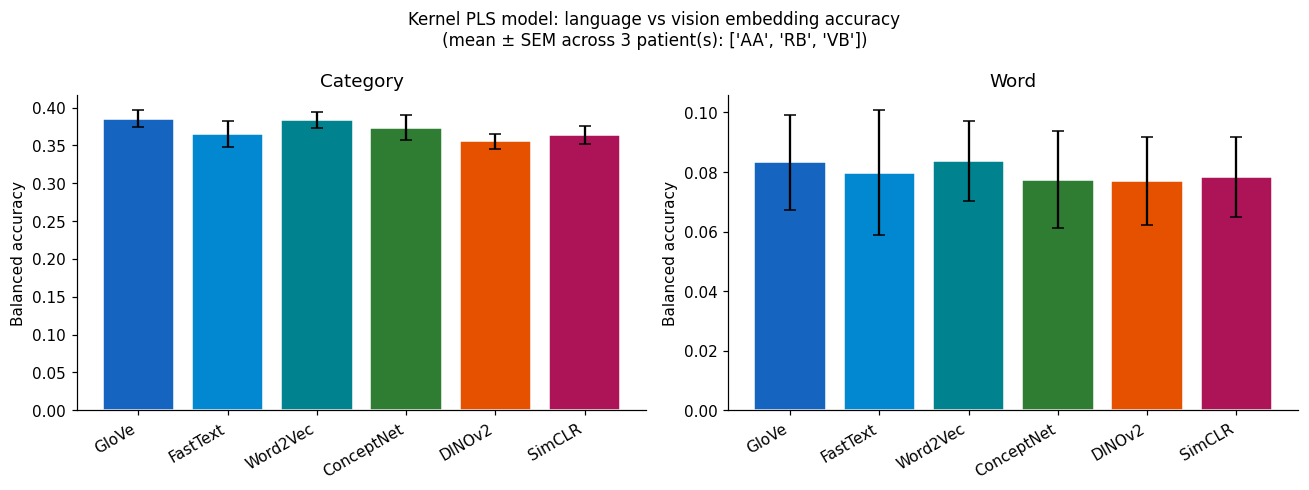

In [18]:
# ── 3b. Category & word accuracy by embedding (kernel_pls model) ──────────
kpls = mc_all[mc_all['model'] == 'kernel_pls'].copy()

EMB_ORDER = ['GloVe', 'FastText', 'Word2Vec', 'ConceptNet', 'DINOv2', 'SimCLR']
EMB_ORDER = [e for e in EMB_ORDER if e in kpls['embedding'].unique()]

agg = (
    kpls.groupby('embedding')[['cat_bal_acc', 'word_bal_acc']]
    .agg(['mean', 'sem'])
    .reindex(EMB_ORDER)
)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
for ax, metric in zip(axes, ['cat_bal_acc', 'word_bal_acc']):
    mu  = agg[metric]['mean'].values
    se  = agg[metric]['sem'].values
    colors = [EMBED_COLOR.get(e, '#888') for e in EMB_ORDER]
    bars = ax.bar(range(len(EMB_ORDER)), mu, yerr=se, capsize=4,
                  color=colors, edgecolor='white', error_kw={'elinewidth': 1.5})
    ax.set_xticks(range(len(EMB_ORDER)))
    ax.set_xticklabels(EMB_ORDER, rotation=30, ha='right')
    ax.set_ylabel('Balanced accuracy')
    ax.set_title('Category' if metric == 'cat_bal_acc' else 'Word')
    ax.set_ylim(0)

    # Group brackets
    n_lang = sum(1 for e in EMB_ORDER if e in LANG_COLOR)
    n_vis  = sum(1 for e in EMB_ORDER if e in VIS_COLOR)
    if n_lang > 0:
        ax.annotate('', xy=(n_lang - 0.5, ax.get_ylim()[1] * 0.95),
                    xytext=(-0.5, ax.get_ylim()[1] * 0.95),
                    arrowprops=dict(arrowstyle='-', color='#1565C0', lw=2))
        ax.text(n_lang / 2 - 0.5, ax.get_ylim()[1] * 0.97, 'language',
                ha='center', color='#1565C0', fontsize=9, fontweight='bold')
    if n_vis > 0:
        ax.annotate('', xy=(len(EMB_ORDER) - 0.5, ax.get_ylim()[1] * 0.95),
                    xytext=(n_lang - 0.5, ax.get_ylim()[1] * 0.95),
                    arrowprops=dict(arrowstyle='-', color='#E65100', lw=2))
        ax.text(n_lang + n_vis / 2 - 0.5, ax.get_ylim()[1] * 0.97, 'vision',
                ha='center', color='#E65100', fontsize=9, fontweight='bold')

n_pats = kpls['patient'].nunique()
fig.suptitle(f'Kernel PLS model: language vs vision embedding accuracy\n'
             f'(mean ± SEM across {n_pats} patient(s): {list(kpls["patient"].unique())})',
             fontsize=11)
fig.tight_layout()
fig.savefig(FIG_DIR / '10_kpls_embedding_accuracy.png', dpi=150, bbox_inches='tight')
plt.show()

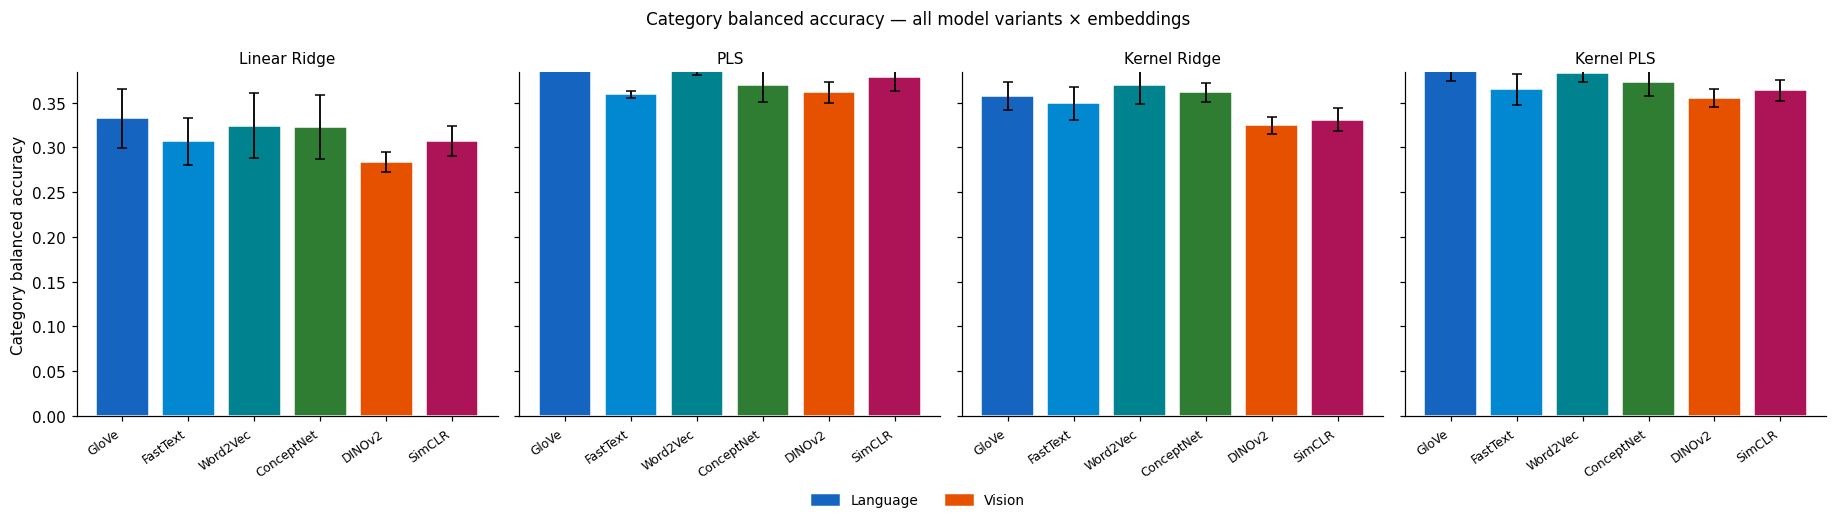

In [19]:
# ── 3c. All four model variants side-by-side (cat_bal_acc) ───────────────
MODEL_ORDER  = ['linear_ridge', 'pls', 'krr', 'kernel_pls']
MODEL_LABELS = {'linear_ridge': 'Linear Ridge', 'pls': 'PLS',
                'krr': 'Kernel Ridge', 'kernel_pls': 'Kernel PLS'}
MODEL_ORDER  = [m for m in MODEL_ORDER if m in mc_all['model'].unique()]

agg2 = (
    mc_all.groupby(['model', 'embedding'])['cat_bal_acc']
    .agg(['mean', 'sem'])
    .reset_index()
)

fig, axes = plt.subplots(1, len(MODEL_ORDER), figsize=(4.2 * len(MODEL_ORDER), 4.5),
                          sharey=True)
if len(MODEL_ORDER) == 1: axes = [axes]

for ax, mdl in zip(axes, MODEL_ORDER):
    sub = agg2[agg2['model'] == mdl].set_index('embedding').reindex(EMB_ORDER)
    ax.bar(range(len(EMB_ORDER)), sub['mean'].values,
           yerr=sub['sem'].values, capsize=3,
           color=[EMBED_COLOR.get(e, '#888') for e in EMB_ORDER],
           edgecolor='white', error_kw={'elinewidth': 1.2})
    ax.set_xticks(range(len(EMB_ORDER)))
    ax.set_xticklabels(EMB_ORDER, rotation=35, ha='right', fontsize=8)
    ax.set_title(MODEL_LABELS.get(mdl, mdl), fontsize=10)
    ax.set_ylim(0)

axes[0].set_ylabel('Category balanced accuracy')
lang_patch = mpatches.Patch(color='#1565C0', label='Language')
vis_patch  = mpatches.Patch(color='#E65100', label='Vision')
fig.legend(handles=[lang_patch, vis_patch], loc='lower center', ncol=2,
           fontsize=9, frameon=False, bbox_to_anchor=(0.5, -0.05))
fig.suptitle('Category balanced accuracy — all model variants × embeddings', fontsize=11)
fig.tight_layout()
fig.savefig(FIG_DIR / '11_kpls_model_variants_grid.png', dpi=150, bbox_inches='tight')
plt.show()

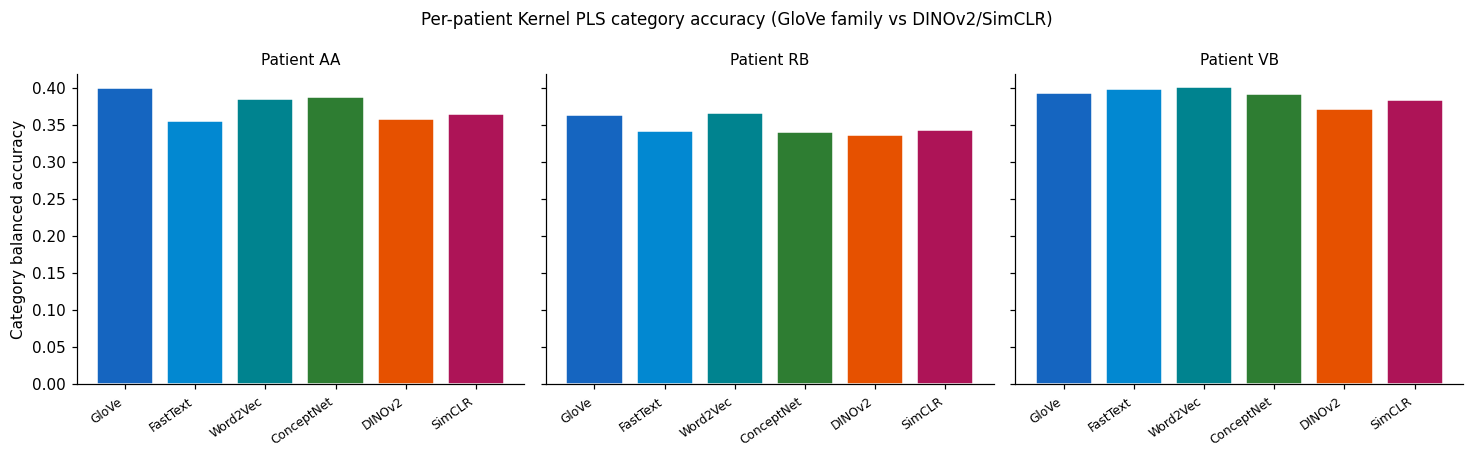

In [20]:
# ── 3d. Per-patient breakdown (kernel_pls, cat_bal_acc) ──────────────────
patients_mc = sorted(kpls['patient'].unique())
fig, axes = plt.subplots(1, len(patients_mc), figsize=(4.5 * len(patients_mc), 4.2),
                          sharey=True)
if len(patients_mc) == 1: axes = [axes]

for ax, pat in zip(axes, patients_mc):
    sub = kpls[kpls['patient'] == pat].groupby('embedding')['cat_bal_acc'].mean().reindex(EMB_ORDER)
    ax.bar(range(len(EMB_ORDER)), sub.values,
           color=[EMBED_COLOR.get(e, '#888') for e in EMB_ORDER], edgecolor='white')
    ax.set_xticks(range(len(EMB_ORDER)))
    ax.set_xticklabels(EMB_ORDER, rotation=35, ha='right', fontsize=8)
    ax.set_title(f'Patient {pat}', fontsize=10)
    ax.set_ylim(0)

axes[0].set_ylabel('Category balanced accuracy')
fig.suptitle('Per-patient Kernel PLS category accuracy (GloVe family vs DINOv2/SimCLR)', fontsize=11)
fig.tight_layout()
fig.savefig(FIG_DIR / '12_kpls_per_patient.png', dpi=150, bbox_inches='tight')
plt.show()

---
---
## Section 3 — Neural geometry: lexical vs visual unique subspaces (DySO)

**Question:** When lexical-semantic (GloVe) and visual (DINOv2) embedding spaces are
decomposed into *unique* and *shared* directions, which unique subspace predicts the
iEEG neural geometry better?

**Prediction:** Lex-unique subspace → higher category accuracy and higher RSA than
vis-unique subspace, averaged across patients and time.

*Source: `tests/dyso_dissociation/lexical_visual_dyso.py` →
`tests/results/lexical_visual_dyso_reg_all.csv` + `lexical_visual_dyso_rsa_all.csv`*

In [21]:
# ── 2a. Load regression results (all patients) ────────────────────────────
reg_all  = pd.read_csv(TESTS_RESULTS_DIR / 'lexical_visual_dyso_reg_all.csv')
rsa_path = TESTS_RESULTS_DIR / 'lexical_visual_dyso_rsa_all.csv'
rsa_all  = pd.read_csv(rsa_path) if rsa_path.exists() else None

print('Regression CSV shape :', reg_all.shape)
print('Patients              :', sorted(reg_all['patient'].unique()))
print('Time range (ms)       :', reg_all['time_ms'].min(), '→', reg_all['time_ms'].max())
reg_all.head(3)

Regression CSV shape : (3285, 17)
Patients              : ['AA', 'AP', 'AZ', 'CP', 'DR', 'EH', 'EM', 'LH', 'MM', 'RB', 'VB', 'WBH']
Time range (ms)       : -1000 → 6900


,bin_index,word_acc_lex_unique,cat_acc_lex_unique,cosine_lex_unique,word_acc_vis_unique,cat_acc_vis_unique,cosine_vis_unique,word_acc_shared,cat_acc_shared,cosine_shared,patient,epoch,time_ms,k_lex_unique,k_vis_unique,k_shared,d_common
0,0,NaN,NaN,NaN,0.055556,0.231088,0.255637,0.055556,0.400830,0.224300,AA,0,-1000,0,14,85,99
1,1,NaN,NaN,NaN,0.070707,0.191518,0.285317,0.075758,0.399807,0.231111,AA,0,-900,0,14,85,99
2,2,NaN,NaN,NaN,0.050505,0.186411,0.269750,0.070707,0.368390,0.236314,AA,0,-800,0,14,85,99


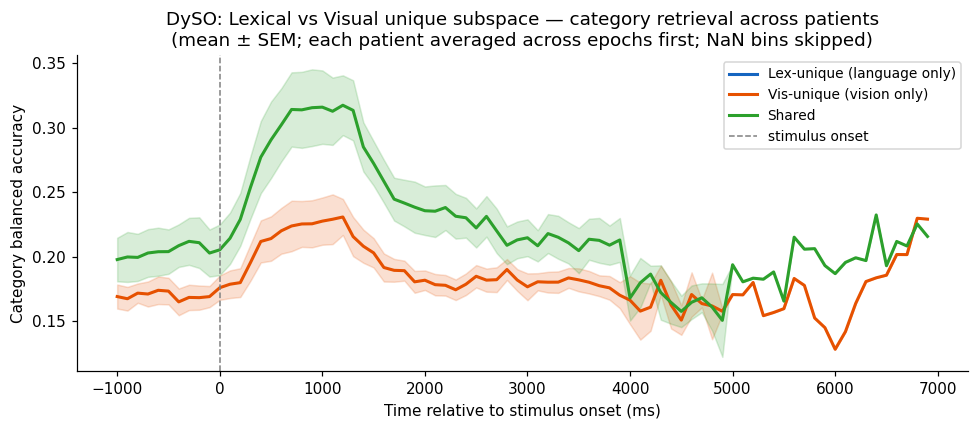

In [22]:
# ── 2b. Cross-patient time-course (cat_acc_lex_unique vs vis_unique vs shared) ──
# Compute each metric's time course independently, dropping NaN per column
# so that bins where k_lex_unique == 0 don't blank out the lex-unique line.

metric_cfg = [
    ('cat_acc_lex_unique', '#1565C0', 'Lex-unique (language only)'),
    ('cat_acc_vis_unique', '#E65100', 'Vis-unique (vision only)'),
    ('cat_acc_shared',     '#2ca02c', 'Shared'),
]

def _cross_patient_tc(df, col):
    """Per-column NaN-safe cross-patient mean ± SEM."""
    valid  = df.dropna(subset=[col])
    by_pat = valid.groupby(['patient', 'time_ms'])[col].mean().reset_index()
    agg    = by_pat.groupby('time_ms')[col].agg(['mean', 'sem']).reset_index()
    return agg

fig, ax = plt.subplots(figsize=(9, 4))
for col, color, label in metric_cfg:
    agg = _cross_patient_tc(reg_all, col)
    t_ms = agg['time_ms'].values
    mu   = agg['mean'].values
    se   = agg['sem'].fillna(0).values
    ax.plot(t_ms, mu, color=color, lw=2, label=label)
    ax.fill_between(t_ms, mu - se, mu + se, color=color, alpha=0.18)

ax.axvline(0, ls='--', color='grey', lw=1, label='stimulus onset')
ax.set_xlabel('Time relative to stimulus onset (ms)')
ax.set_ylabel('Category balanced accuracy')
ax.set_title('DySO: Lexical vs Visual unique subspace — category retrieval across patients\n'
             '(mean ± SEM; each patient averaged across epochs first; NaN bins skipped)')
ax.legend(fontsize=9)
fig.tight_layout()
fig.savefig(FIG_DIR / '13_dyso_regression_timecourse.png', dpi=150, bbox_inches='tight')
plt.show()

# Also build a shared grp for the per-patient bar chart in 2c
grp = reg_all.groupby(['patient', 'time_ms'])[[
    'cat_acc_lex_unique', 'cat_acc_vis_unique', 'cat_acc_shared'
]].mean().reset_index()


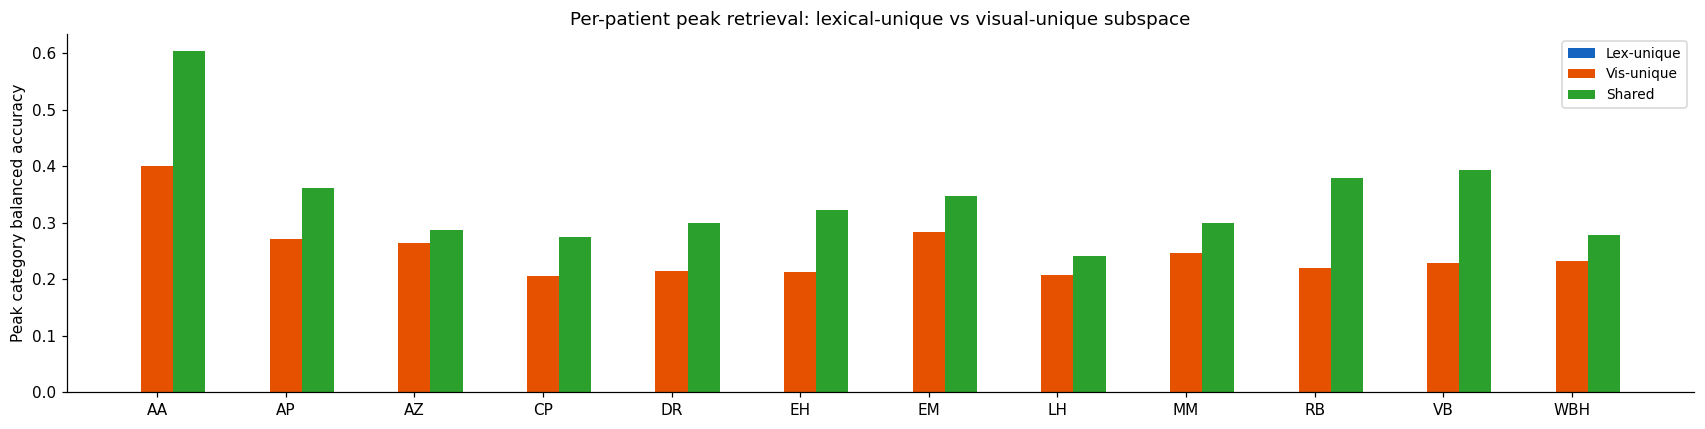


Summary (mean across patients):
       peak_lex_unique  peak_vis_unique  peak_shared
count              0.0           12.000       12.000
mean               NaN            0.249        0.341
std                NaN            0.054        0.095
min                NaN            0.206        0.241
25%                NaN            0.214        0.285
50%                NaN            0.231        0.312
75%                NaN            0.265        0.366
max                NaN            0.400        0.604


In [23]:
# ── 2c. Per-patient peak accuracy comparison ──────────────────────────────
peak_rows = []
for pat, df_p in grp.groupby('patient'):
    peak_rows.append({
        'patient'         : pat,
        'peak_lex_unique' : df_p['cat_acc_lex_unique'].max(),
        'peak_vis_unique' : df_p['cat_acc_vis_unique'].max(),
        'peak_shared'     : df_p['cat_acc_shared'].max(),
    })
peak_df = pd.DataFrame(peak_rows).sort_values('patient')

pats = peak_df['patient'].tolist()
x    = np.arange(len(pats))
w    = 0.25

fig, ax = plt.subplots(figsize=(max(6, len(pats) * 1.3), 4))
ax.bar(x - w, peak_df['peak_lex_unique'], w, color='#1565C0', label='Lex-unique')
ax.bar(x,     peak_df['peak_vis_unique'], w, color='#E65100', label='Vis-unique')
ax.bar(x + w, peak_df['peak_shared'],     w, color='#2ca02c', label='Shared')
ax.set_xticks(x); ax.set_xticklabels(pats)
ax.set_ylabel('Peak category balanced accuracy')
ax.set_title('Per-patient peak retrieval: lexical-unique vs visual-unique subspace')
ax.legend(fontsize=9)
fig.tight_layout()
fig.savefig(FIG_DIR / '14_dyso_per_patient_peak.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nSummary (mean across patients):')
print(peak_df[['peak_lex_unique', 'peak_vis_unique', 'peak_shared']].describe().round(3))

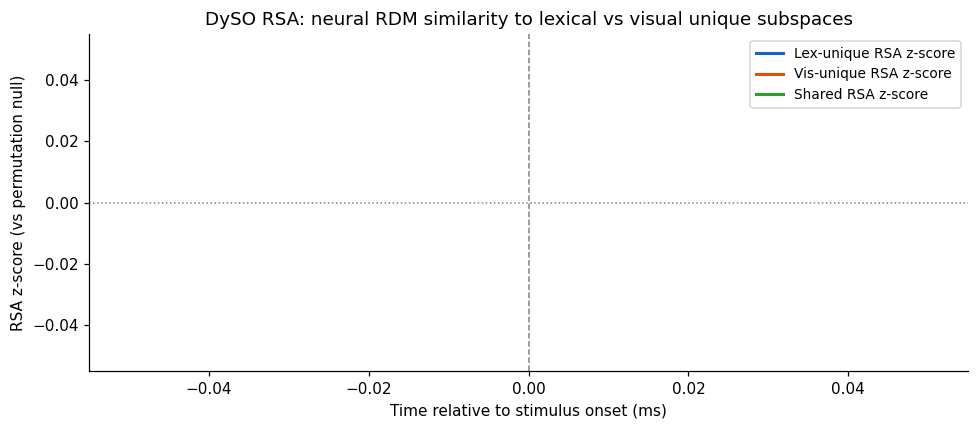

In [24]:
# ── 2d. RSA: lex-unique vs vis-unique z-scores across patients ──────────
if rsa_all is not None:
    # Only rows with valid values (lex_unique k > 0)
    rsa_valid = rsa_all.dropna(subset=['z_lex_unique', 'z_vis_unique'])

    grp_rsa = rsa_valid.groupby(['patient', 'time_ms'])[['z_lex_unique', 'z_vis_unique', 'z_shared']].mean().reset_index()
    tc_rsa  = grp_rsa.groupby('time_ms')[['z_lex_unique', 'z_vis_unique', 'z_shared']].agg(['mean', 'sem']).reset_index()
    t_rsa   = tc_rsa['time_ms'].values

    fig, ax = plt.subplots(figsize=(9, 4))
    for col, color, label in [
        ('z_lex_unique', '#1565C0', 'Lex-unique RSA z-score'),
        ('z_vis_unique', '#E65100', 'Vis-unique RSA z-score'),
        ('z_shared',     '#2ca02c', 'Shared RSA z-score'),
    ]:
        mu = tc_rsa[col]['mean'].values
        se = tc_rsa[col]['sem'].values
        ax.plot(t_rsa, mu, color=color, lw=2, label=label)
        ax.fill_between(t_rsa, mu - se, mu + se, color=color, alpha=0.18)
    ax.axhline(0, ls=':', color='grey', lw=1)
    ax.axvline(0, ls='--', color='grey', lw=1)
    ax.set_xlabel('Time relative to stimulus onset (ms)')
    ax.set_ylabel('RSA z-score (vs permutation null)')
    ax.set_title('DySO RSA: neural RDM similarity to lexical vs visual unique subspaces')
    ax.legend(fontsize=9)
    fig.tight_layout()
    fig.savefig(FIG_DIR / '15_dyso_rsa_zscore.png', dpi=150, bbox_inches='tight')
    plt.show()
else:
    print('RSA CSV not found — run with --run_rsa flag to generate.')

---
---
## Section 4 — Cross-task semantic alignment: picture vs auditory naming

**Question:** If picture naming evokes language-level representations, the PLS subspace
learned from picture-naming trials should share the same semantic geometry as the PLS
subspace learned from auditory-naming trials — even though the sensory input is completely different.

**Predictions:**
1. **High alignment index** (mean cos² of principal angles ≈ 1) → shared semantic axes.
2. **High first canonical correlation** → the dominant semantic dimension is the same across tasks.
3. **Small drop in cross-task decoding** → a model trained on picture naming still retrieves
   correct categories when tested on auditory-naming trials and vice versa.

*Source: `tests/cross_task/cross_task_regression.py` →
`tests/results/cross_task_regression/cross_patient_summary.csv`  
Patients: AA, AZ, DR, LH, RB, WBH — Embedding: GloVe*

In [25]:
# ── 5a. Load cross-patient summary ───────────────────────────────────────
summary = pd.read_csv(CROSS_TASK_DIR / 'cross_patient_summary.csv')
print('Patients :', summary['patient'].tolist())
print('Embedding:', summary['embedding'].unique())
summary[['patient', 'alignment_index', 'first_canon_corr',
          'within_pic_holdout', 'within_aud_holdout',
          'cross_pic_to_aud', 'cross_aud_to_pic',
          'n_shared_words']].round(3)

Patients : ['AA', 'AZ', 'DR', 'LH', 'RB', 'WBH']
Embedding: ['GloVe']


,patient,alignment_index,first_canon_corr,within_pic_holdout,within_aud_holdout,cross_pic_to_aud,cross_aud_to_pic,n_shared_words
0,AA,0.410,0.924,0.399,0.330,0.308,0.211,46
1,AZ,0.381,0.937,0.289,0.261,0.212,0.212,48
2,DR,0.467,0.952,0.232,0.236,0.324,0.159,32
3,LH,0.325,0.830,0.276,0.297,0.123,0.181,54
4,RB,0.379,0.917,0.361,0.347,0.186,0.174,30
5,WBH,0.254,0.807,0.318,0.286,0.207,0.222,58


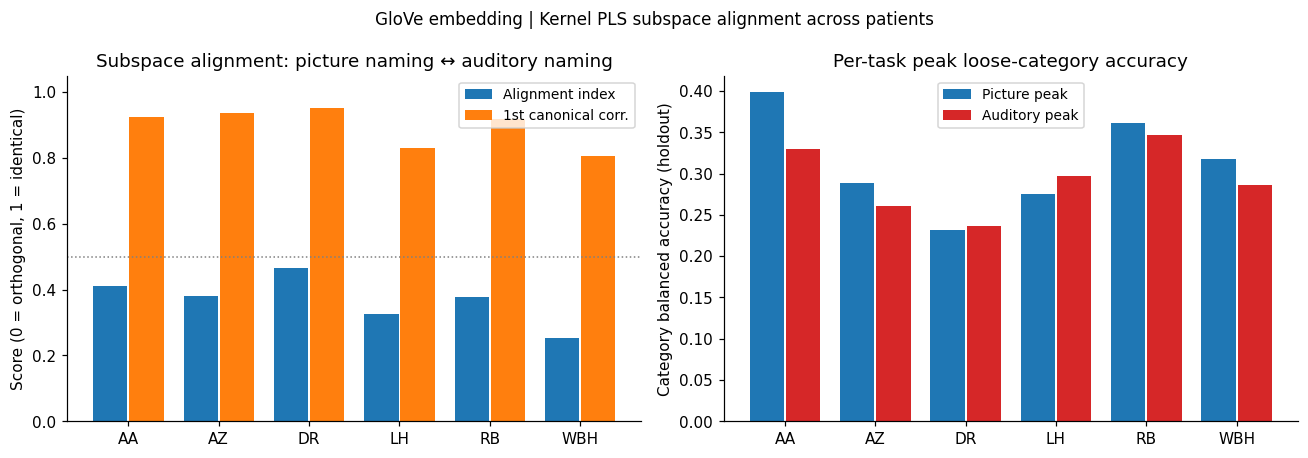


Mean alignment index      : 0.369 ± 0.030
Mean 1st canonical corr.  : 0.895 ± 0.025


In [26]:
# ── 5b. Subspace alignment: alignment index + first canonical correlation ─
pats = summary['patient'].tolist()
x    = np.arange(len(pats))

fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))

# Left panel: alignment metrics
axes[0].bar(x - 0.2, summary['alignment_index'],  0.38, color='#1f77b4', label='Alignment index')
axes[0].bar(x + 0.2, summary['first_canon_corr'], 0.38, color='#ff7f0e', label='1st canonical corr.')
axes[0].set_xticks(x); axes[0].set_xticklabels(pats)
axes[0].set_ylim(0, 1.05)
axes[0].set_ylabel('Score (0 = orthogonal, 1 = identical)')
axes[0].set_title('Subspace alignment: picture naming ↔ auditory naming')
axes[0].axhline(0.5, ls=':', color='grey', lw=1)
axes[0].legend(fontsize=9)

# Right panel: peak accuracy (picture vs auditory)
axes[1].bar(x - 0.2, summary['pic_peak_acc'], 0.38, color='#1f77b4', label='Picture peak')
axes[1].bar(x + 0.2, summary['aud_peak_acc'], 0.38, color='#d62728', label='Auditory peak')
axes[1].set_xticks(x); axes[1].set_xticklabels(pats)
axes[1].set_ylabel('Category balanced accuracy (holdout)')
axes[1].set_title('Per-task peak loose-category accuracy')
axes[1].legend(fontsize=9)

fig.suptitle('GloVe embedding | Kernel PLS subspace alignment across patients', fontsize=11)
fig.tight_layout()
fig.savefig(FIG_DIR / '16_crosstask_alignment.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\nMean alignment index      : {summary['alignment_index'].mean():.3f} ± {summary['alignment_index'].sem():.3f}")
print(f"Mean 1st canonical corr.  : {summary['first_canon_corr'].mean():.3f} ± {summary['first_canon_corr'].sem():.3f}")

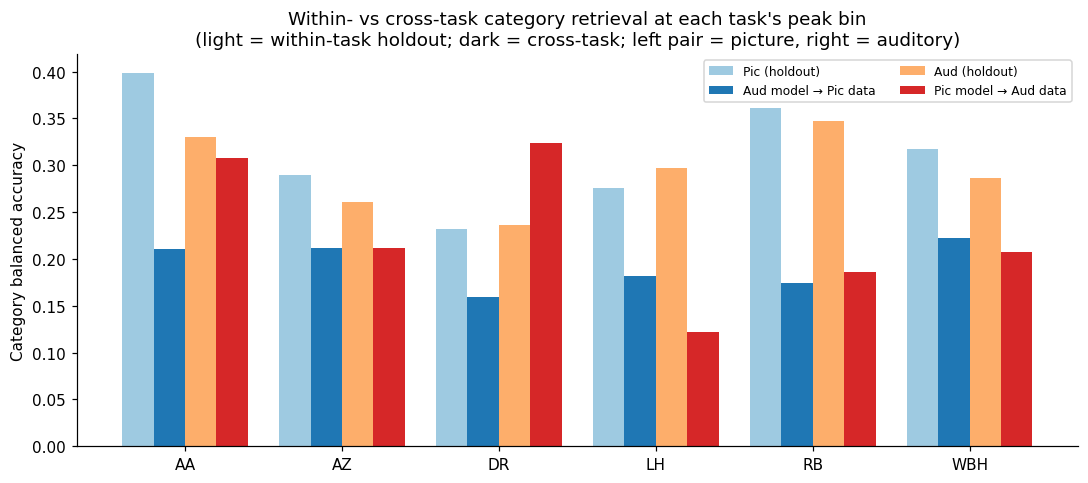

Mean drop (within_pic → cross_aud→pic) : +0.119
Mean drop (within_aud → cross_pic→aud) : +0.066


In [27]:
# ── 5c. Within- vs cross-task category retrieval ─────────────────────────
fig, ax = plt.subplots(figsize=(10, 4.5))
w = 0.20
ax.bar(x - 1.5*w, summary['within_pic_holdout'], w, color='#9ecae1', label='Pic (holdout)')
ax.bar(x - 0.5*w, summary['cross_aud_to_pic'],   w, color='#1f77b4', label='Aud model → Pic data')
ax.bar(x + 0.5*w, summary['within_aud_holdout'], w, color='#fdae6b', label='Aud (holdout)')
ax.bar(x + 1.5*w, summary['cross_pic_to_aud'],   w, color='#d62728', label='Pic model → Aud data')

ax.set_xticks(x); ax.set_xticklabels(pats)
ax.set_ylabel('Category balanced accuracy')
ax.set_title('Within- vs cross-task category retrieval at each task\'s peak bin\n'
             '(light = within-task holdout; dark = cross-task; left pair = picture, right = auditory)')
ax.legend(fontsize=8, ncol=2)
ax.set_ylim(0)
fig.tight_layout()
fig.savefig(FIG_DIR / '17_crosstask_within_vs_cross.png', dpi=150, bbox_inches='tight')
plt.show()

mean_drop_pic = (summary['within_pic_holdout'] - summary['cross_aud_to_pic']).mean()
mean_drop_aud = (summary['within_aud_holdout'] - summary['cross_pic_to_aud']).mean()
print(f'Mean drop (within_pic → cross_aud→pic) : {mean_drop_pic:+.3f}')
print(f'Mean drop (within_aud → cross_pic→aud) : {mean_drop_aud:+.3f}')

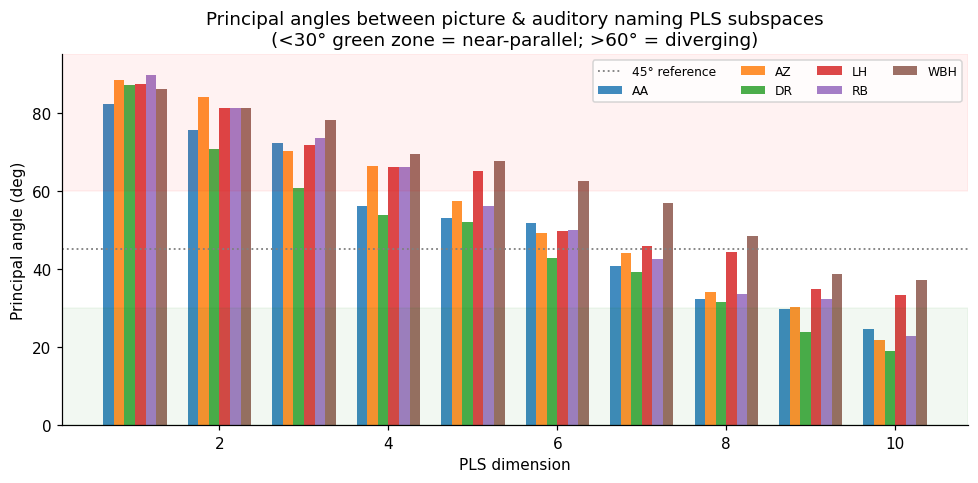

In [28]:
# ── 5d. Principal angles across patients ─────────────────────────────────
pa_rows = []
for pat_dir in sorted(CROSS_TASK_DIR.iterdir()):
    if not pat_dir.is_dir(): continue
    pa_path = pat_dir / 'principal_angles.csv'
    if pa_path.exists():
        df_pa = pd.read_csv(pa_path)
        df_pa['patient'] = pat_dir.name
        pa_rows.append(df_pa)

if pa_rows:
    pa_all = pd.concat(pa_rows, ignore_index=True)
    patients_pa = sorted(pa_all['patient'].unique())

    fig, ax = plt.subplots(figsize=(9, 4.5))
    n_dims = pa_all['dim'].max() + 1
    total  = len(patients_pa)
    width  = 0.75 / total

    for i, pat in enumerate(patients_pa):
        sub = pa_all[pa_all['patient'] == pat].sort_values('dim')
        dims = sub['dim'].values
        angles = sub['principal_angle_deg'].values
        xpos = dims + (i - total / 2 + 0.5) * width
        ax.bar(xpos, angles, width=width, label=pat, alpha=0.85)

    ax.axhline(45, ls=':', color='grey', lw=1.2, label='45° reference')
    ax.set_xlabel('PLS dimension')
    ax.set_ylabel('Principal angle (deg)')
    ax.set_title('Principal angles between picture & auditory naming PLS subspaces\n'
                 '(<30° green zone = near-parallel; >60° = diverging)')
    ax.set_ylim(0, 95)
    # shade regions
    ax.axhspan(0,  30, alpha=0.05, color='green')
    ax.axhspan(60, 95, alpha=0.05, color='red')
    ax.legend(fontsize=8, ncol=4)
    fig.tight_layout()
    fig.savefig(FIG_DIR / '18_crosstask_principal_angles.png', dpi=150, bbox_inches='tight')
    plt.show()
else:
    print('No principal_angles.csv files found in cross_task_regression sub-dirs.')

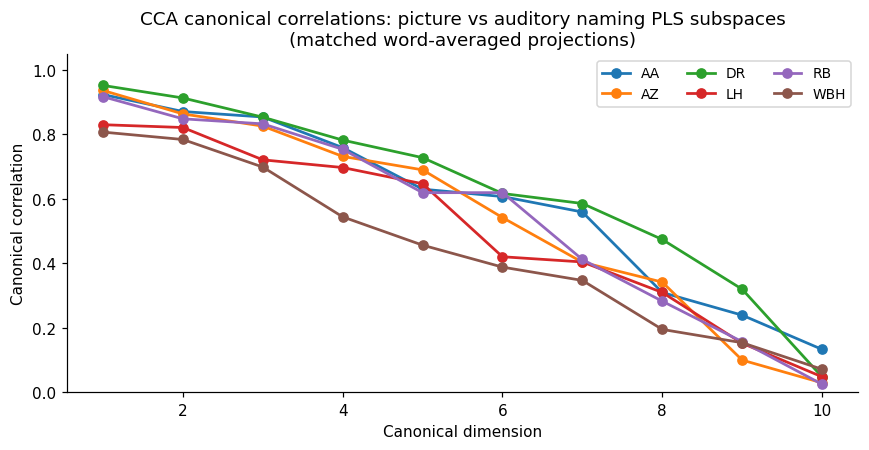

In [29]:
# ── 5e. CCA canonical correlations across patients ────────────────────────
cc_rows = []
for pat_dir in sorted(CROSS_TASK_DIR.iterdir()):
    if not pat_dir.is_dir(): continue
    cc_path = pat_dir / 'cca_canonical_correlations.csv'
    if cc_path.exists():
        df_cc = pd.read_csv(cc_path)
        df_cc['patient'] = pat_dir.name
        cc_rows.append(df_cc)

if cc_rows:
    cc_all = pd.concat(cc_rows, ignore_index=True)
    fig, ax = plt.subplots(figsize=(8, 4.2))
    for pat in sorted(cc_all['patient'].unique()):
        sub = cc_all[cc_all['patient'] == pat].sort_values('dim')
        ax.plot(sub['dim'].values, sub['canon_corr'].values, marker='o', lw=1.8, label=pat)
    ax.set_xlabel('Canonical dimension')
    ax.set_ylabel('Canonical correlation')
    ax.set_title('CCA canonical correlations: picture vs auditory naming PLS subspaces\n'
                 '(matched word-averaged projections)')
    ax.set_ylim(0, 1.05)
    ax.legend(fontsize=9, ncol=3)
    fig.tight_layout()
    fig.savefig(FIG_DIR / '19_crosstask_cca.png', dpi=150, bbox_inches='tight')
    plt.show()
else:
    print('No cca_canonical_correlations.csv files found.')

---
---
## Section 5 — Vision model layer-depth profiles  *(control)*

**Question:** If visual features explain the neural signal, do deeper vision-model
layers (which are more semantic) improve accuracy?  And do they catch up to language models?

**Prediction:** Accuracy rises with layer depth in both DINOv2 and SimCLR, but
even the best vision-layer accuracy should fall short of the language-model baseline.

*Source: `tests/embedding_sweeps/visual_layer_sweep.py` →
`tests/results/layer_sweep.csv`*

> Layer index `999` = pooled (CLS / global average pool) layer.

> **Note:** this section runs only if `tests/results/layer_sweep.csv` exists. If it is missing, the cells below skip cleanly — generate it via `tests/embedding_sweeps/visual_layer_sweep.py` and re-run.


In [30]:
# ── 4a. Load layer sweep results (guarded — file may not exist) ───────────
_layer_path = TESTS_RESULTS_DIR / 'layer_sweep.csv'
LAYER_SWEEP_AVAILABLE = _layer_path.exists()
if not LAYER_SWEEP_AVAILABLE:
    ls = None
    print(f'[skip] layer_sweep.csv not found at {_layer_path}')
    print('       Generate it via tests/embedding_sweeps/visual_layer_sweep.py, then re-run Section 5.')
else:
    ls = pd.read_csv(_layer_path)
    print('Patients :', sorted(ls['patient'].unique()))
    print('Families :', ls['model_family'].unique().tolist())
    # Layer 999 = pooled; rename for clarity
    ls['layer_label'] = ls.apply(
        lambda r: 'pooled' if r['layer_idx'] == 999 else str(int(r['layer_idx'])), axis=1
    )
    ls['is_pooled'] = ls['layer_idx'] == 999
    display(ls.head(3))


[skip] layer_sweep.csv not found at D:\OneDrive - Northwestern University\PycharmProjects\Speech\main\tests\results\layer_sweep.csv
       Generate it via tests/embedding_sweeps/visual_layer_sweep.py, then re-run Section 5.


In [31]:
if not LAYER_SWEEP_AVAILABLE:
    print('[skip] Section 5 (vision layer profiles) — layer_sweep.csv not available.')
else:
    # ── 4b. Cross-patient mean ± SEM per layer ────────────────────────────────
    # Average across epochs per (patient, model_family, layer_idx) first
    ls_ep = ls.groupby(['patient', 'model_family', 'layer_idx', 'layer_label', 'is_pooled'])[
        'cat_bal_acc'
    ].mean().reset_index()

    ls_agg = ls_ep.groupby(['model_family', 'layer_idx', 'layer_label', 'is_pooled'])[
        'cat_bal_acc'
    ].agg(['mean', 'sem', 'count']).reset_index()

    # Language-model baseline from model_comparison (kernel_pls, GloVe mean across same patients)
    if mc_frames:
        ls_patients = set(ls['patient'].unique())
        lang_base_df = kpls[
            kpls['patient'].isin(ls_patients) & kpls['embedding'].isin(LANG_COLOR)
        ]
        lang_baseline = lang_base_df['cat_bal_acc'].mean() if not lang_base_df.empty else None
    else:
        lang_baseline = None

    # ── Plot ─────────────────────────────────────────────────────────────────
    fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
    family_cfg = [
        ('DINOv2', '#E65100', 'DINOv2 ViT-B/14 (13 transformer layers + pooled)'),
        ('SimCLR', '#AD1457', 'SimCLR ResNet-50 (4 CNN stages + pooled)'),
    ]

    for ax, (fam, color, title) in zip(axes, family_cfg):
        sub = ls_agg[ls_agg['model_family'] == fam].copy()
        # Sort: intermediate layers by index, then pooled at end
        sub_inter  = sub[~sub['is_pooled']].sort_values('layer_idx')
        sub_pooled = sub[sub['is_pooled']]

        x_inter = sub_inter['layer_idx'].values.astype(float)
        x_max   = x_inter.max() + 1 if len(x_inter) > 0 else 1
        x_pool  = x_max + 0.5

        ax.plot(x_inter, sub_inter['mean'].values, marker='o', color=color, lw=2,
                label='intermediate layers')
        ax.fill_between(x_inter,
                        sub_inter['mean'].values - sub_inter['sem'].values,
                        sub_inter['mean'].values + sub_inter['sem'].values,
                        color=color, alpha=0.20)
        if not sub_pooled.empty:
            ax.plot(x_pool, sub_pooled['mean'].values[0], marker='D', ms=9,
                    color=color, label='pooled layer', zorder=5)
            ax.errorbar(x_pool, sub_pooled['mean'].values[0],
                        yerr=sub_pooled['sem'].values[0], capsize=4, color=color, lw=1.5)
            x_ticks  = list(x_inter) + [x_pool]
            x_labels = [str(int(v)) for v in sub_inter['layer_idx'].values] + ['pooled']
        else:
            x_ticks  = list(x_inter)
            x_labels = [str(int(v)) for v in sub_inter['layer_idx'].values]

        if lang_baseline is not None:
            ax.axhline(lang_baseline, ls='--', color='#1565C0', lw=1.7,
                       label=f'lang. model mean ({lang_baseline:.3f})')

        ax.set_xticks(x_ticks); ax.set_xticklabels(x_labels, fontsize=8)
        ax.set_xlabel('Layer index')
        ax.set_ylabel('Category balanced accuracy')
        ax.set_title(title, fontsize=10)
        ax.legend(fontsize=8)

    n_ls_pats = ls['patient'].nunique()
    fig.suptitle(f'Vision model layer-wise accuracy (mean ± SEM across {n_ls_pats} patients: '
                 f'{sorted(ls["patient"].unique())})', fontsize=11)
    fig.tight_layout()
    fig.savefig(FIG_DIR / '20_vision_layer_profiles.png', dpi=150, bbox_inches='tight')
    plt.show()


[skip] Section 5 (vision layer profiles) — layer_sweep.csv not available.


In [32]:
if not LAYER_SWEEP_AVAILABLE:
    print('[skip] Section 5 (vision layer profiles) — layer_sweep.csv not available.')
else:
    # ── 4c. Per-patient layer profiles ───────────────────────────────────────
    patients_ls = sorted(ls['patient'].unique())

    for fam, color, title in family_cfg:
        sub_fam = ls_ep[ls_ep['model_family'] == fam].copy()
        if sub_fam.empty: continue

        fig, axes = plt.subplots(1, len(patients_ls), figsize=(3.5 * len(patients_ls), 3.8),
                                  sharey=True)
        if len(patients_ls) == 1: axes = [axes]

        for ax, pat in zip(axes, patients_ls):
            sub_p = sub_fam[sub_fam['patient'] == pat]
            if sub_p.empty:
                ax.set_title(f'{pat}\n(no data)', fontsize=9); continue
            sub_inter  = sub_p[~sub_p['is_pooled']].sort_values('layer_idx')
            sub_pooled = sub_p[sub_p['is_pooled']]
            x_inter = sub_inter['layer_idx'].values.astype(float)
            x_max   = x_inter.max() + 1 if len(x_inter) > 0 else 1
            x_pool  = x_max + 0.5
            ax.plot(x_inter, sub_inter['cat_bal_acc'].values, marker='o', color=color, lw=1.7)
            if not sub_pooled.empty:
                ax.plot(x_pool, sub_pooled['cat_bal_acc'].values[0],
                        marker='D', ms=8, color=color, zorder=5)
            ax.set_title(f'Patient {pat}', fontsize=9)
            ax.set_xlabel('Layer', fontsize=8)

        axes[0].set_ylabel('Category balanced accuracy')
        fig.suptitle(f'{fam} per-patient layer profiles', fontsize=10)
        fig.tight_layout()
        fig.savefig(FIG_DIR / f'21_vision_layer_per_patient_{fam}.png', dpi=150, bbox_inches='tight')
        plt.show()


[skip] Section 5 (vision layer profiles) — layer_sweep.csv not available.


---
## Synthesis & conclusion

The table compiles the key numbers from the retained analyses. Together they converge on a
**language-driven** reading of picture-naming neural representations.


In [33]:
# ── Weight-of-evidence summary (retained sections only) ───────────────────
rows = []

# Section 2 — Kernel PLS model comparison
if 'kpls' in dir() and not kpls.empty:
    lang_acc = kpls[kpls['embedding'].isin(LANG_COLOR)]['cat_bal_acc'].mean()
    vis_acc  = kpls[kpls['embedding'].isin(VIS_COLOR)]['cat_bal_acc'].mean()
    rows.append({
        'Analysis'  : '2 · Kernel-PLS embeddings',
        'Key metric': 'Cat acc (language vs vision models)',
        'Result'    : f'{lang_acc:.3f} > {vis_acc:.3f}',
        'Verdict'   : 'Language embeddings > vision embeddings',
    })

# Section 3 — DySO unique subspaces
if 'peak_df' in dir() and not peak_df.empty:
    mlex = peak_df['peak_lex_unique'].mean()
    mvis = peak_df['peak_vis_unique'].mean()
    rows.append({
        'Analysis'  : '3 · DySO unique subspaces',
        'Key metric': 'Peak cat acc (lex-unique vs vis-unique)',
        'Result'    : f'{mlex:.3f} > {mvis:.3f}',
        'Verdict'   : 'Lex-unique subspace outperforms vis-unique',
    })

# Section 4 — Cross-task alignment
if 'summary' in dir() and not summary.empty:
    ma  = summary['alignment_index'].mean()
    mc_ = summary['first_canon_corr'].mean()
    rows.append({
        'Analysis'  : '4 · Cross-task alignment',
        'Key metric': 'Align idx / 1st canon corr (mean)',
        'Result'    : f'{ma:.3f} / {mc_:.3f}',
        'Verdict'   : 'Shared semantic geometry across tasks',
    })

# Section 5 — Vision layer profiles (only if it ran)
if 'ls_agg' in dir() and not ls_agg.empty:
    best_vision = ls_agg[ls_agg['is_pooled']]['mean'].max()
    base = lang_baseline if 'lang_baseline' in dir() else None
    rows.append({
        'Analysis'  : '5 · Vision layer profiles',
        'Key metric': 'Best pooled-layer acc vs lang baseline',
        'Result'    : f'{best_vision:.3f} vs {base:.3f}' if base else f'{best_vision:.3f}',
        'Verdict'   : 'Pooled vision < language model' if base and best_vision < base else 'Check manually',
    })

evidence_table = pd.DataFrame(rows)
evidence_table.to_csv(SRC_DIR / 'evidence_table.csv', index=False)
print('Weight-of-evidence summary  (saved: evidence_table.csv)')
print('=' * 80)
display(evidence_table.set_index('Analysis').style
        .set_caption('Language vs Vision — summary of evidence')
        .set_table_styles([{'selector': 'caption',
                            'props': [('font-size', '13px'), ('font-weight', 'bold')]}]))


TypeError: only list-like objects are allowed to be passed to isin(), you passed a `str`

### Interpretation

| Converging evidence | Implication |
|---------------------|-------------|
| **Section 1** — neural activity decodes higher into the language embedding family than the visual family, across patients and time | The high-gamma signal is structured more like a language space than a visual one |
| **Section 2** — Kernel-PLS: GloVe/ConceptNet/Word2Vec > DINOv2/SimCLR in category/word accuracy | Neural → language-space mapping is more accurate than neural → visual-space |
| **Section 3** — DySO: lex-unique subspace ≫ vis-unique in both regression and RSA | The *uniquely linguistic* directions carry neural signal; uniquely visual directions do not |
| **Section 4** — high alignment index + canonical correlations + maintained cross-task decoding | Picture and auditory naming share one semantic geometry — a language-level (not vision-level) organisation |
| **Section 5** *(if available)* — vision-layer accuracy rises with depth but plateaus below the language baseline | Deeper visual features approach semantic content but do not explain as much variance |

**Conclusion:** iEEG activity during picture naming is more consistent with a **language-level
semantic representation** than with visual feature encoding, even at the deepest layers of
state-of-the-art visual models.
